In [2]:
# =============================================================================
# XÁC MINH CHỮ KÝ VIẾT TAY - CEDAR DATASET
# Mô hình: CNN Embedding + XgBoost
# =============================================================================

# ============================================================
# CELL 1: Cài đặt thư viện
# ============================================================
!pip install xgboost -q
!pip install gdown -q

import os
import random
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_curve, auc
)
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

import warnings
warnings.filterwarnings('ignore')

# Seed cho reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️ Device: {device}")

🖥️ Device: cuda


In [3]:
# ============================================================
# CELL 2: Tải và giải nén CEDAR Dataset
# ============================================================
"""
CEDAR Dataset chứa chữ ký của 55 người:
- Mỗi người: 24 chữ ký thật + 24 chữ ký giả mạo
- Tổng: 1320 thật + 1320 giả = 2640 ảnh
"""

import os

DATA_DIR = '/content/drive/MyDrive/dataset_ndm/signatures'

if not os.path.exists(DATA_DIR):
    print("⚠️ Thư mục dataset không tồn tại. Vui lòng đảm bảo CEDAR dataset đã được tải và giải nén tại /content/CEDAR/")
else:
    print("✅ Dataset đã tồn tại!")

# Kiểm tra cấu trúc thư mục
for root, dirs, files in os.walk(DATA_DIR):
    level = root.replace(DATA_DIR, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:
        subindent = ' ' * 2 * (level + 1)
        for f in files[:3]:
            print(f'{subindent}{f}')
        if len(files) > 3:
            print(f'{subindent}... ({len(files)} files)')

✅ Dataset đã tồn tại!
signatures/
  Readme.txt
  full_forg/
    forgeries_19_20.png
    forgeries_21_14.png
    forgeries_17_1.png
    ... (1321 files)
  full_org/
    original_24_22.png
    original_1_14.png
    original_27_20.png
    ... (1321 files)
  trained_models/
    best_signature_model.pth
    final_signature_model.pth


In [4]:
# ============================================================
# CELL 3: Tổ chức dữ liệu và tiền xử lý
# ============================================================

class CEDARDataOrganizer:
    """
    Tổ chức dữ liệu CEDAR thành cấu trúc phù hợp.

    CEDAR structure:
    - full_org/original_{person}_{sample}.png  (chữ ký thật)
    - full_forg/forgeries_{person}_{sample}.png (chữ ký giả)
    """

    def __init__(self, data_dir, img_size=(155, 220)):
        self.data_dir = data_dir
        self.img_size = img_size
        self.num_persons = 55
        self.num_samples = 24  # 24 thật + 24 giả mỗi người

        # Tìm đường dẫn chính xác
        self.orig_dir = '/content/drive/MyDrive/dataset_ndm/signatures/full_org'
        self.forg_dir = '/content/drive/MyDrive/dataset_ndm/signatures/full_forg'

        print(f"📁 Thư mục chữ ký thật: {self.orig_dir}")
        print(f"📁 Thư mục chữ ký giả: {self.forg_dir}")

    def _find_dir(self, keyword):
        """Tìm thư mục chứa ảnh theo keyword"""
        for root, dirs, files in os.walk(self.data_dir):
            for d in dirs:
                if keyword in d.lower() or 'org' in d.lower():
                    path = os.path.join(root, d)
                    if any(f.endswith('.png') or f.endswith('.PNG')
                           for f in os.listdir(path)):
                        if keyword == 'original' and 'org' in d.lower():
                            return path
                        elif keyword == 'forgeries' and 'forg' in d.lower():
                            return path
            # Tìm trong files
            for f in files:
                if keyword in f.lower():
                    return root
        return None

    def preprocess_image(self, img_path):
        """
        Tiền xử lý ảnh chữ ký theo pipeline:
        1. Đọc ảnh grayscale
        2. Resize về kích thước cố định (nội suy song tuyến tính)
        3. Gaussian blur (khử nhiễu)
        4. Otsu thresholding (nhị phân hóa)
        5. Centering (dịch chữ ký về trung tâm)
        6. Inversion (nền = 0, chữ ký = 1)
        """
        # Đọc ảnh grayscale
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise ValueError(f"Không đọc được ảnh: {img_path}")

        # Resize bằng nội suy song tuyến tính
        img = cv2.resize(img, (self.img_size[1], self.img_size[0]),
                         interpolation=cv2.INTER_LINEAR)

        # Gaussian blur - khử nhiễu
        img = cv2.GaussianBlur(img, (3, 3), 0)

        # Otsu thresholding - nhị phân hóa
        _, img = cv2.threshold(img, 0, 255,
                               cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        # Inversion: nền = 0, chữ ký = 255
        # Kiểm tra xem nền sáng hay tối
        if np.mean(img) > 127:
            img = 255 - img

        # Centering - dịch chữ ký về trung tâm
        img = self._center_signature(img)

        # Normalize về [0, 1]
        img = img.astype(np.float32) / 255.0

        return img

    def _center_signature(self, img):
        """Dịch chữ ký về trung tâm ảnh"""
        coords = cv2.findNonZero(img)
        if coords is None:
            return img

        x, y, w, h = cv2.boundingRect(coords)
        signature = img[y:y+h, x:x+w]

        # Tạo ảnh mới với chữ ký ở trung tâm
        result = np.zeros_like(img)
        y_offset = (img.shape[0] - h) // 2
        x_offset = (img.shape[1] - w) // 2

        # Đảm bảo không vượt quá kích thước
        h_place = min(h, img.shape[0] - y_offset)
        w_place = min(w, img.shape[1] - x_offset)

        result[y_offset:y_offset+h_place,
               x_offset:x_offset+w_place] = signature[:h_place, :w_place]

        return result

    def load_all_data(self):
        """
        Load toàn bộ dữ liệu, trả về dict:
        {person_id: {'genuine': [imgs], 'forged': [imgs]}}
        """
        data = defaultdict(lambda: {'genuine': [], 'forged': []})

        # Load chữ ký thật
        if self.orig_dir:
            for f in sorted(os.listdir(self.orig_dir)):
                if not (f.endswith('.png') or f.endswith('.PNG')):
                    continue
                parts = f.replace('.png', '').replace('.PNG', '').split('_')
                try:
                    person_id = int(parts[1])
                    img_path = os.path.join(self.orig_dir, f)
                    img = self.preprocess_image(img_path)
                    data[person_id]['genuine'].append(img)
                except (IndexError, ValueError):
                    continue

        # Load chữ ký giả
        if self.forg_dir:
            for f in sorted(os.listdir(self.forg_dir)):
                if not (f.endswith('.png') or f.endswith('.PNG')):
                    continue
                parts = f.replace('.png', '').replace('.PNG', '').split('_')
                try:
                    person_id = int(parts[1])
                    img_path = os.path.join(self.forg_dir, f)
                    img = self.preprocess_image(img_path)
                    data[person_id]['forged'].append(img)
                except (IndexError, ValueError):
                    continue

        print(f"\n📊 Thống kê dữ liệu:")
        print(f"   Số người: {len(data)}")
        total_genuine = sum(len(v['genuine']) for v in data.values())
        total_forged = sum(len(v['forged']) for v in data.values())
        print(f"   Tổng chữ ký thật: {total_genuine}")
        print(f"   Tổng chữ ký giả: {total_forged}")

        return dict(data)


# Load dữ liệu
organizer = CEDARDataOrganizer(DATA_DIR, img_size=(155, 220))
all_data = organizer.load_all_data()

📁 Thư mục chữ ký thật: /content/drive/MyDrive/dataset_ndm/signatures/full_org
📁 Thư mục chữ ký giả: /content/drive/MyDrive/dataset_ndm/signatures/full_forg

📊 Thống kê dữ liệu:
   Số người: 55
   Tổng chữ ký thật: 1320
   Tổng chữ ký giả: 1320


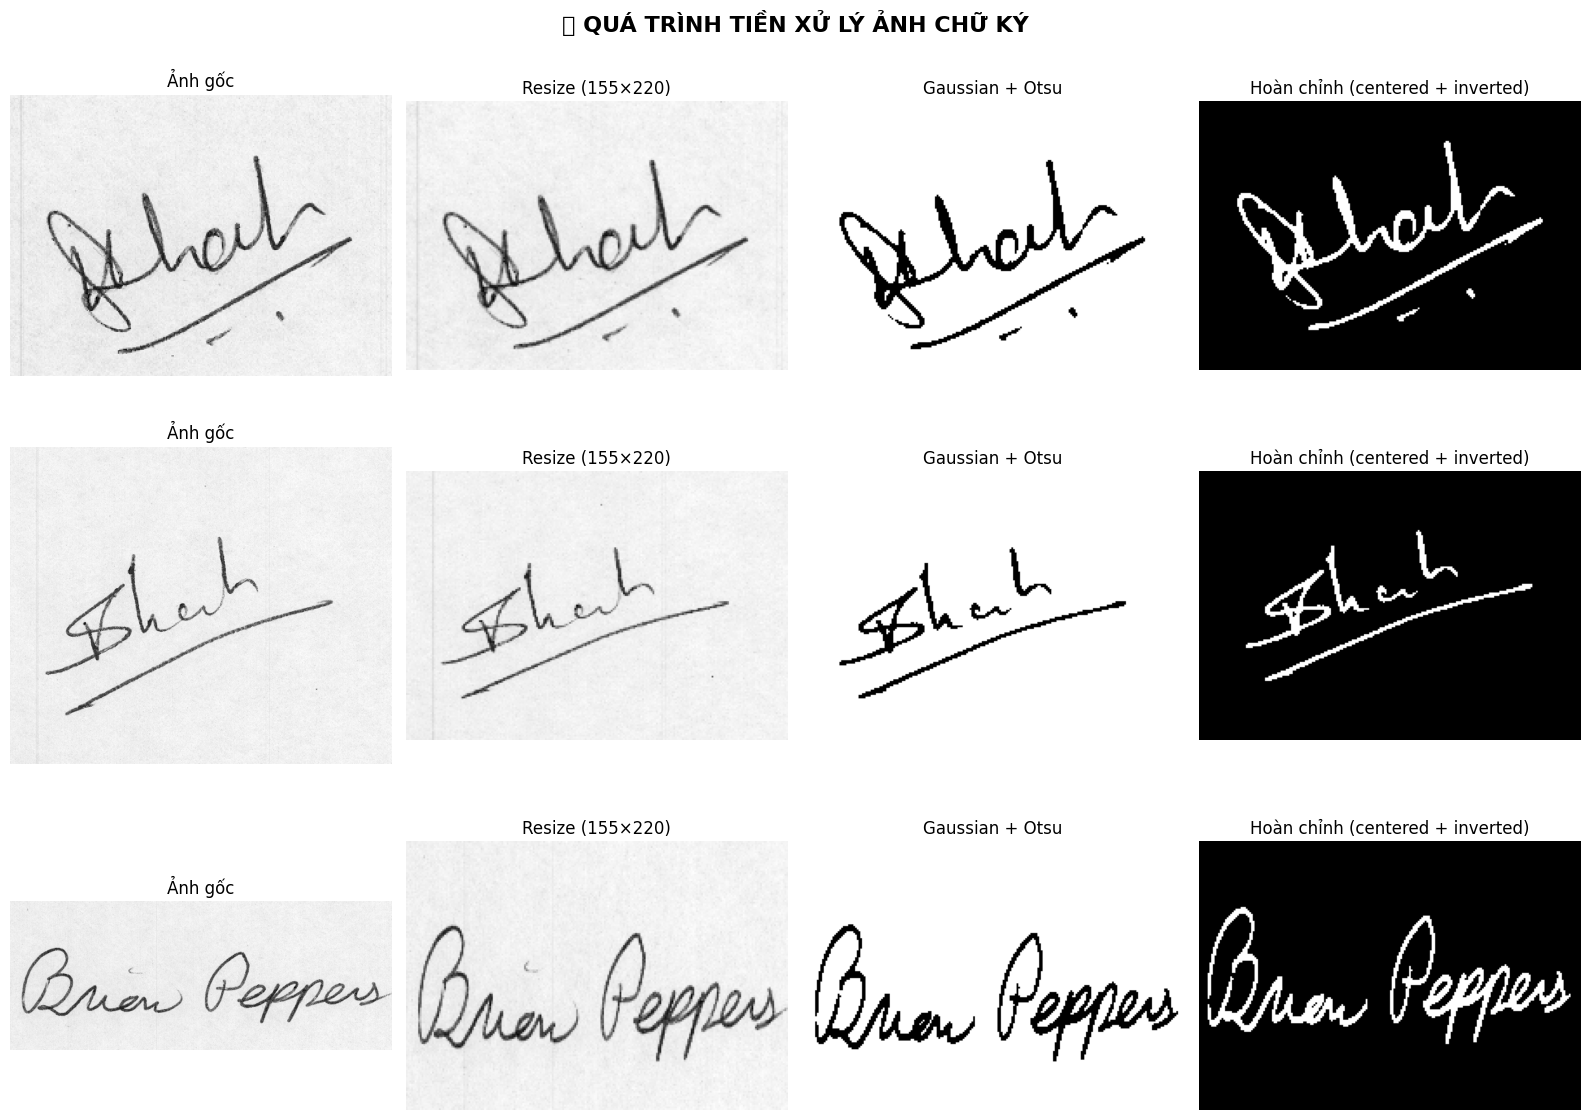

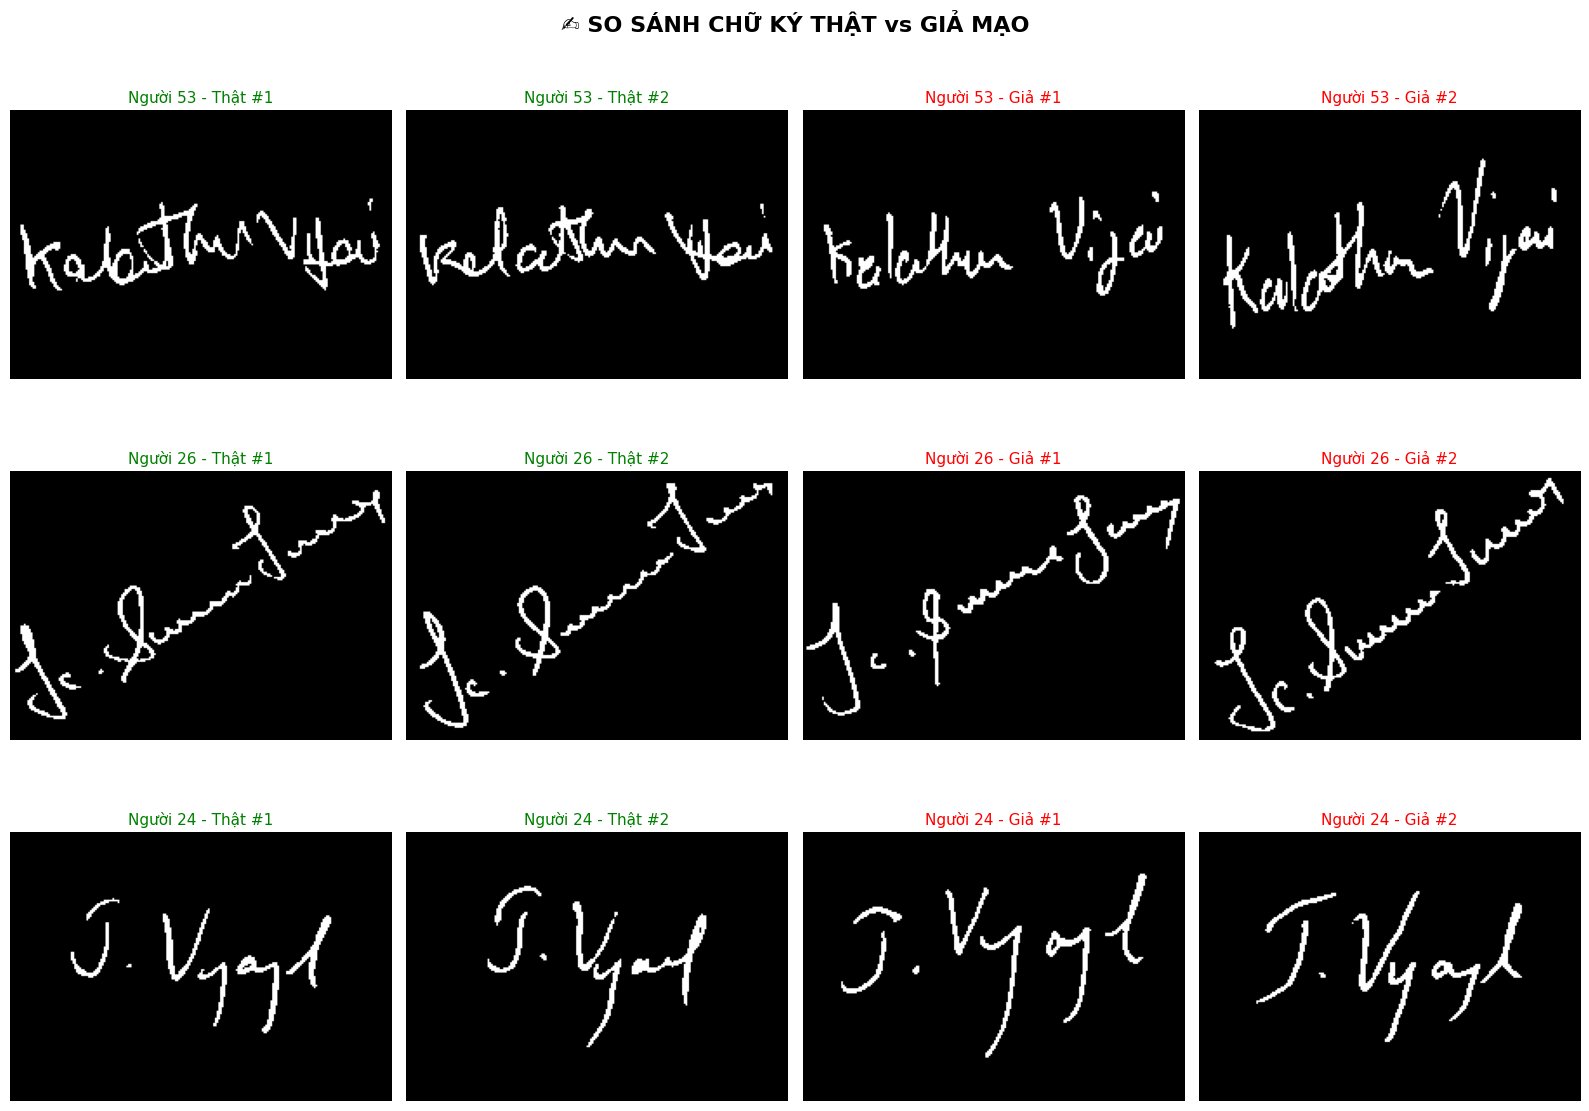

In [5]:
# ============================================================
# CELL 4: Visualization - Minh họa tiền xử lý
# ============================================================

def visualize_preprocessing(organizer, n_samples=3):
    """Minh họa quá trình tiền xử lý"""
    fig, axes = plt.subplots(n_samples, 4, figsize=(16, 4*n_samples))

    sample_files = []
    if organizer.orig_dir:
        files = [f for f in os.listdir(organizer.orig_dir)
                 if f.endswith('.png') or f.endswith('.PNG')]
        sample_files = random.sample(files, min(n_samples, len(files)))

    for i, f in enumerate(sample_files):
        img_path = os.path.join(organizer.orig_dir, f)

        # Ảnh gốc
        orig = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        axes[i, 0].imshow(orig, cmap='gray')
        axes[i, 0].set_title('Ảnh gốc', fontsize=12)

        # Resize
        resized = cv2.resize(orig, (220, 155), interpolation=cv2.INTER_LINEAR)
        axes[i, 1].imshow(resized, cmap='gray')
        axes[i, 1].set_title('Resize (155×220)', fontsize=12)

        # Gaussian + Otsu
        blurred = cv2.GaussianBlur(resized, (3, 3), 0)
        _, binary = cv2.threshold(blurred, 0, 255,
                                   cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        axes[i, 2].imshow(binary, cmap='gray')
        axes[i, 2].set_title('Gaussian + Otsu', fontsize=12)

        # Tiền xử lý hoàn chỉnh
        processed = organizer.preprocess_image(img_path)
        axes[i, 3].imshow(processed, cmap='gray')
        axes[i, 3].set_title('Hoàn chỉnh (centered + inverted)', fontsize=12)

        for j in range(4):
            axes[i, j].axis('off')

    plt.suptitle('🔄 QUÁ TRÌNH TIỀN XỬ LÝ ẢNH CHỮ KÝ', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

def visualize_genuine_vs_forged(all_data, n_persons=3):
    """So sánh chữ ký thật và giả"""
    persons = random.sample(list(all_data.keys()), min(n_persons, len(all_data)))
    fig, axes = plt.subplots(n_persons, 4, figsize=(16, 4*n_persons))

    for i, pid in enumerate(persons):
        genuine = all_data[pid]['genuine']
        forged = all_data[pid]['forged']

        # 2 chữ ký thật
        for j in range(2):
            if j < len(genuine):
                axes[i, j].imshow(genuine[j], cmap='gray')
            axes[i, j].set_title(f'Người {pid} - Thật #{j+1}',
                                fontsize=11, color='green')
            axes[i, j].axis('off')

        # 2 chữ ký giả
        for j in range(2):
            if j < len(forged):
                axes[i, j+2].imshow(forged[j], cmap='gray')
            axes[i, j+2].set_title(f'Người {pid} - Giả #{j+1}',
                                   fontsize=11, color='red')
            axes[i, j+2].axis('off')

    plt.suptitle('✍️ SO SÁNH CHỮ KÝ THẬT vs GIẢ MẠO', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

visualize_preprocessing(organizer)
visualize_genuine_vs_forged(all_data)

In [6]:
# ============================================================
# CELL 5: Chia dữ liệu Train / Validation / Test
# ============================================================

def split_data(all_data, n_train=45, n_val=5, n_test=5):
    """
    Chia dữ liệu theo người:
    - Training + Validation: 50 người (chia 8:2)
    - Testing: 5 người
    """
    person_ids = sorted(all_data.keys())
    assert len(person_ids) >= n_train + n_test, \
        f"Cần ít nhất {n_train + n_test} người, chỉ có {len(person_ids)}"

    random.shuffle(person_ids)

    # Chia theo mô hình Embedding: 50 người train+val, 5 người test
    train_val_persons = person_ids[:n_train + n_val]
    test_persons = person_ids[n_train + n_val:]

    # Chia train_val thành train (80%) và val (20%)
    n_tv = len(train_val_persons)
    n_t = int(n_tv * 0.8)
    train_persons = train_val_persons[:n_t]
    val_persons = train_val_persons[n_t:]

    print(f"📊 Phân chia dữ liệu:")
    print(f"   Train: {len(train_persons)} người - IDs: {sorted(train_persons)[:5]}...")
    print(f"   Val:   {len(val_persons)} người - IDs: {sorted(val_persons)}")
    print(f"   Test:  {len(test_persons)} người - IDs: {sorted(test_persons)}")

    return train_persons, val_persons, test_persons

train_persons, val_persons, test_persons = split_data(all_data)

📊 Phân chia dữ liệu:
   Train: 40 người - IDs: [1, 4, 5, 8, 10]...
   Val:   10 người - IDs: [2, 3, 6, 14, 28, 35, 38, 50, 53, 55]
   Test:  5 người - IDs: [7, 9, 15, 44, 48]


In [7]:
# ============================================================
# CELL 6: Dataset cho Embedding Network (Multi-task Learning)
# ============================================================

class EmbeddingTrainDataset(Dataset):
    """
    Dataset cho huấn luyện mạng Embedding.
    Mỗi sample: (image, person_id, is_genuine)

    Multi-task:
    - Task 1: Phân loại người ký (Categorical Cross Entropy)
    - Task 2: Phân loại thật/giả (Binary Cross Entropy)
    """

    def __init__(self, all_data, person_ids, transform=None):
        self.transform = transform
        self.samples = []  # (image, person_label, is_genuine)

        # Tạo mapping person_id -> label (0, 1, 2, ...)
        self.person_to_label = {pid: idx for idx, pid
                                 in enumerate(sorted(person_ids))}
        self.num_persons = len(person_ids)

        for pid in person_ids:
            label = self.person_to_label[pid]

            # Chữ ký thật
            for img in all_data[pid]['genuine']:
                self.samples.append((img, label, 1))  # is_genuine = 1

            # Chữ ký giả
            for img in all_data[pid]['forged']:
                self.samples.append((img, label, 0))  # is_genuine = 0

        random.shuffle(self.samples)
        print(f"   Dataset: {len(self.samples)} samples, "
              f"{self.num_persons} persons")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img, person_label, is_genuine = self.samples[idx]

        # Convert to tensor [1, H, W]
        img_tensor = torch.FloatTensor(img).unsqueeze(0)

        if self.transform:
            img_tensor = self.transform(img_tensor)

        return img_tensor, person_label, is_genuine


class PairTestDataset(Dataset):
    """
    Dataset cho testing: tạo cặp ảnh (reference, query).
    Trả về embedding vectors đã tính sẵn hoặc ảnh để tính.
    """

    def __init__(self, all_data, person_ids, n_ref=12):
        """
        n_ref: số ảnh reference cho mỗi người (còn lại dùng để test)
        """
        self.pairs = []  # (ref_img, query_img, label)

        for pid in person_ids:
            genuine = all_data[pid]['genuine']
            forged = all_data[pid]['forged']

            if len(genuine) < n_ref + 1:
                n_ref_actual = len(genuine) // 2
            else:
                n_ref_actual = n_ref

            ref_imgs = genuine[:n_ref_actual]
            query_genuine = genuine[n_ref_actual:]

            # Cặp thật-thật (label = 1)
            for q_img in query_genuine:
                for r_img in ref_imgs:
                    self.pairs.append((r_img, q_img, 1))

            # Cặp thật-giả (label = 0)
            for f_img in forged:
                for r_img in ref_imgs:
                    self.pairs.append((r_img, f_img, 0))

        print(f"   Test pairs: {len(self.pairs)} "
              f"(genuine pairs + forged pairs)")

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        ref_img, query_img, label = self.pairs[idx]
        ref_tensor = torch.FloatTensor(ref_img).unsqueeze(0)
        query_tensor = torch.FloatTensor(query_img).unsqueeze(0)
        return ref_tensor, query_tensor, label


# Data augmentation cho training
train_transform = transforms.Compose([
    transforms.RandomAffine(degrees=5, translate=(0.05, 0.05), scale=(0.95, 1.05)),
])

# Tạo datasets
print("🔧 Tạo Training Dataset:")
train_dataset = EmbeddingTrainDataset(all_data, train_persons,
                                       transform=train_transform)
print("🔧 Tạo Validation Dataset:")
val_dataset = EmbeddingTrainDataset(all_data, val_persons)
print("🔧 Tạo Test Dataset:")
test_dataset = PairTestDataset(all_data, test_persons, n_ref=12)

# DataLoaders
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                           shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE,
                         shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2)


🔧 Tạo Training Dataset:
   Dataset: 1920 samples, 40 persons
🔧 Tạo Validation Dataset:
   Dataset: 480 samples, 10 persons
🔧 Tạo Test Dataset:
   Test pairs: 2160 (genuine pairs + forged pairs)


In [8]:
# ============================================================
# CELL 7: Kiến trúc mạng Embedding (SigNet-based)
# ============================================================

class EmbeddingNetwork(nn.Module):
    """
    Mạng CNN Embedding cho xác minh chữ ký.

    Kiến trúc dựa trên SigNet [Dey et al., 2017] và
    Hafemann et al. (2017), với cải tiến:
    - Batch Normalization thay LRN
    - Multi-task output: person classification + genuine/forged

    Input: ảnh grayscale 1×155×220
    Output: embedding vector 128-D + 2 classification heads
    """

    def __init__(self, num_persons, embedding_dim=128):
        super(EmbeddingNetwork, self).__init__()
        self.embedding_dim = embedding_dim

        # ============ Feature Extraction (FeatNet) ============
        # Block 1
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 96, kernel_size=11, stride=1, padding=5),
            nn.BatchNorm2d(96),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
        )

        # Block 2
        self.conv2 = nn.Sequential(
            nn.Conv2d(96, 256, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
        )

        # Block 3
        self.conv3 = nn.Sequential(
            nn.Conv2d(256, 384, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(384),
            nn.ReLU(inplace=True),
        )

        # Block 4
        self.conv4 = nn.Sequential(
            nn.Conv2d(384, 384, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(384),
            nn.ReLU(inplace=True),
        )

        # Block 5
        self.conv5 = nn.Sequential(
            nn.Conv2d(384, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
        )

        # Tính kích thước sau convolution
        self._feature_size = self._get_conv_output_size()

        # ============ Embedding Layer ============
        self.embedding = nn.Sequential(
            nn.Linear(self._feature_size, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, embedding_dim),
        )

        # ============ Classification Heads (Multi-task) ============
        # Head 1: Phân loại người ký tên
        self.person_classifier = nn.Sequential(
            nn.Linear(embedding_dim, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_persons),
        )

        # Head 2: Phân loại thật/giả
        self.genuine_classifier = nn.Sequential(
            nn.Linear(embedding_dim, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(64, 1),
        )

        # Khởi tạo trọng số
        self._initialize_weights()

    def _get_conv_output_size(self):
        """Tính kích thước output sau các lớp convolution"""
        dummy = torch.zeros(1, 1, 155, 220)
        x = self.conv1(dummy)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.conv5(x)
        return x.view(1, -1).size(1)

    def _initialize_weights(self):
        """Khởi tạo trọng số theo He initialization"""
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out',
                                        nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight)
                nn.init.constant_(m.bias, 0)

    def extract_features(self, x):
        """Trích xuất embedding vector"""
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.conv5(x)
        x = x.view(x.size(0), -1)
        embedding = self.embedding(x)
        return embedding

    def forward(self, x):
        """
        Forward pass: trả về embedding + 2 predictions
        """
        embedding = self.extract_features(x)

        # Multi-task heads
        person_logits = self.person_classifier(embedding)
        genuine_logits = self.genuine_classifier(embedding)

        return embedding, person_logits, genuine_logits


# Khởi tạo mô hình
num_train_persons = len(train_persons)
model = EmbeddingNetwork(num_persons=num_train_persons,
                          embedding_dim=128).to(device)

# Hiển thị kiến trúc
print("=" * 60)
print("🏗️ KIẾN TRÚC MẠNG EMBEDDING")
print("=" * 60)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Tổng parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Embedding dimension: {model.embedding_dim}")
print(f"Số người (train): {num_train_persons}")
print("=" * 60)
print(model)


🏗️ KIẾN TRÚC MẠNG EMBEDDING
Tổng parameters: 151,170,473
Trainable parameters: 151,170,473
Embedding dimension: 128
Số người (train): 40
EmbeddingNetwork(
  (conv1): Sequential(
    (0): Conv2d(1, 96, kernel_size=(11, 11), stride=(1, 1), padding=(5, 5))
    (1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(96, 256, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv2d(256, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(384, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (conv4): Seq

In [9]:

# ============================================================
# CELL 8: Multi-task Loss Function
# ============================================================

class MultiTaskLoss(nn.Module):
    """
    Multi-task Loss cho mạng Embedding:
    L_total = α * L_person + β * L_genuine

    Trong đó:
    - L_person: Categorical Cross Entropy (phân loại người ký)
    - L_genuine: Binary Cross Entropy (phân loại thật/giả)
    - α, β: Hệ số cân bằng
    """

    def __init__(self, alpha=1.0, beta=0.5):
        super(MultiTaskLoss, self).__init__()
        self.alpha = alpha
        self.beta = beta
        self.person_loss_fn = nn.CrossEntropyLoss()
        self.genuine_loss_fn = nn.BCEWithLogitsLoss()

    def forward(self, person_logits, person_labels,
                genuine_logits, genuine_labels):
        """
        Args:
            person_logits: [B, num_persons]
            person_labels: [B] (class indices)
            genuine_logits: [B, 1]
            genuine_labels: [B] (0 or 1)
        """
        loss_person = self.person_loss_fn(person_logits, person_labels)
        loss_genuine = self.genuine_loss_fn(
            genuine_logits.squeeze(), genuine_labels.float()
        )

        total_loss = self.alpha * loss_person + self.beta * loss_genuine

        return total_loss, loss_person, loss_genuine


criterion = MultiTaskLoss(alpha=1.0, beta=0.5)

In [12]:
# ============================================================
# CELL 9: Huấn luyện mạng Embedding
# ============================================================

def train_embedding_network(model, train_loader, val_loader,
                             criterion, num_epochs=50,
                             initial_lr=0.001):
    """
    Huấn luyện mạng Embedding với:
    - Adam optimizer
    - ReduceLROnPlateau scheduler (giảm lr khi val_loss không giảm)
    - Early stopping
    """
    optimizer = optim.Adam(model.parameters(), lr=initial_lr,
                           weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.1, patience=5
    )

    # Tracking
    history = {
        'train_loss': [], 'val_loss': [],
        'train_person_acc': [], 'val_person_acc': [],
        'train_genuine_acc': [], 'val_genuine_acc': [],
        'lr': []
    }

    best_val_loss = float('inf')
    best_model_state = None
    patience_counter = 0
    early_stop_patience = 10

    print("=" * 70)
    print("🚀 BẮT ĐẦU HUẤN LUYỆN MẠNG EMBEDDING")
    print("=" * 70)

    for epoch in range(num_epochs):
        # =================== Training ===================
        model.train()
        train_loss_sum = 0
        train_person_correct = 0
        train_genuine_correct = 0
        train_total = 0

        for batch_idx, (imgs, person_labels, genuine_labels) in enumerate(train_loader):
            imgs = imgs.to(device)
            person_labels = person_labels.to(device)
            genuine_labels = genuine_labels.to(device)

            optimizer.zero_grad()

            embedding, person_logits, genuine_logits = model(imgs)

            loss, loss_p, loss_g = criterion(
                person_logits, person_labels,
                genuine_logits, genuine_labels
            )

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

            train_loss_sum += loss.item() * imgs.size(0)

            # Accuracy
            _, person_pred = person_logits.max(1)
            train_person_correct += person_pred.eq(person_labels).sum().item()

            genuine_pred = (torch.sigmoid(genuine_logits.squeeze()) > 0.5).long()
            train_genuine_correct += genuine_pred.eq(genuine_labels).sum().item()

            train_total += imgs.size(0)

        train_loss = train_loss_sum / train_total
        train_person_acc = 100. * train_person_correct / train_total
        train_genuine_acc = 100. * train_genuine_correct / train_total

        # =================== Validation ===================
        model.eval()
        val_loss_sum = 0
        val_person_correct = 0
        val_genuine_correct = 0
        val_total = 0

        with torch.no_grad():
            for imgs, person_labels, genuine_labels in val_loader:
                imgs = imgs.to(device)
                person_labels = person_labels.to(device)
                genuine_labels = genuine_labels.to(device)

                embedding, person_logits, genuine_logits = model(imgs)
                loss, _, _ = criterion(person_logits, person_labels,
                                       genuine_logits, genuine_labels)

                val_loss_sum += loss.item() * imgs.size(0)

                _, person_pred = person_logits.max(1)
                val_person_correct += person_pred.eq(person_labels).sum().item()

                genuine_pred = (torch.sigmoid(genuine_logits.squeeze()) > 0.5).long()
                val_genuine_correct += genuine_pred.eq(genuine_labels).sum().item()

                val_total += imgs.size(0)

        val_loss = val_loss_sum / val_total
        val_person_acc = 100. * val_person_correct / val_total
        val_genuine_acc = 100. * val_genuine_correct / val_total

        # Learning rate scheduler
        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']

        # Save history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_person_acc'].append(train_person_acc)
        history['val_person_acc'].append(val_person_acc)
        history['train_genuine_acc'].append(train_genuine_acc)
        history['val_genuine_acc'].append(val_genuine_acc)
        history['lr'].append(current_lr)

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()
            patience_counter = 0
            marker = " ✅ Best"
        else:
            patience_counter += 1
            marker = ""

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1:3d}/{num_epochs}] | "
                  f"Loss: {train_loss:.4f}/{val_loss:.4f} | "
                  f"Person Acc: {train_person_acc:.1f}%/{val_person_acc:.1f}% | "
                  f"G/F Acc: {train_genuine_acc:.1f}%/{val_genuine_acc:.1f}% | "
                  f"LR: {current_lr:.6f}{marker}")

        if patience_counter >= early_stop_patience:
            print(f"\n⏹️ Early stopping tại epoch {epoch+1}")
            break

    # Load best model
    if best_model_state:
        model.load_state_dict(best_model_state)
        print(f"\n✅ Đã load mô hình tốt nhất (val_loss = {best_val_loss:.4f})")

    return model, history


# Huấn luyện
model, history = train_embedding_network(
    model, train_loader, val_loader, criterion,
    num_epochs=60, initial_lr=0.001
)

# Lưu mô hình
torch.save(model.state_dict(), '/content/embedding_model.pth')
print("💾 Đã lưu mô hình!")

🚀 BẮT ĐẦU HUẤN LUYỆN MẠNG EMBEDDING
Epoch [  1/60] | Loss: 85.0345/6.1353 | Person Acc: 3.8%/3.8% | G/F Acc: 49.6%/48.5% | LR: 0.001000 ✅ Best
Epoch [  5/60] | Loss: 4.1658/4.0342 | Person Acc: 3.8%/4.4% | G/F Acc: 51.2%/50.0% | LR: 0.001000 ✅ Best
Epoch [ 10/60] | Loss: 3.8696/6.8742 | Person Acc: 5.6%/0.6% | G/F Acc: 50.4%/45.4% | LR: 0.001000
Epoch [ 15/60] | Loss: 3.5802/5.8787 | Person Acc: 9.0%/3.1% | G/F Acc: 50.4%/41.7% | LR: 0.000100

⏹️ Early stopping tại epoch 15

✅ Đã load mô hình tốt nhất (val_loss = 4.0342)
💾 Đã lưu mô hình!


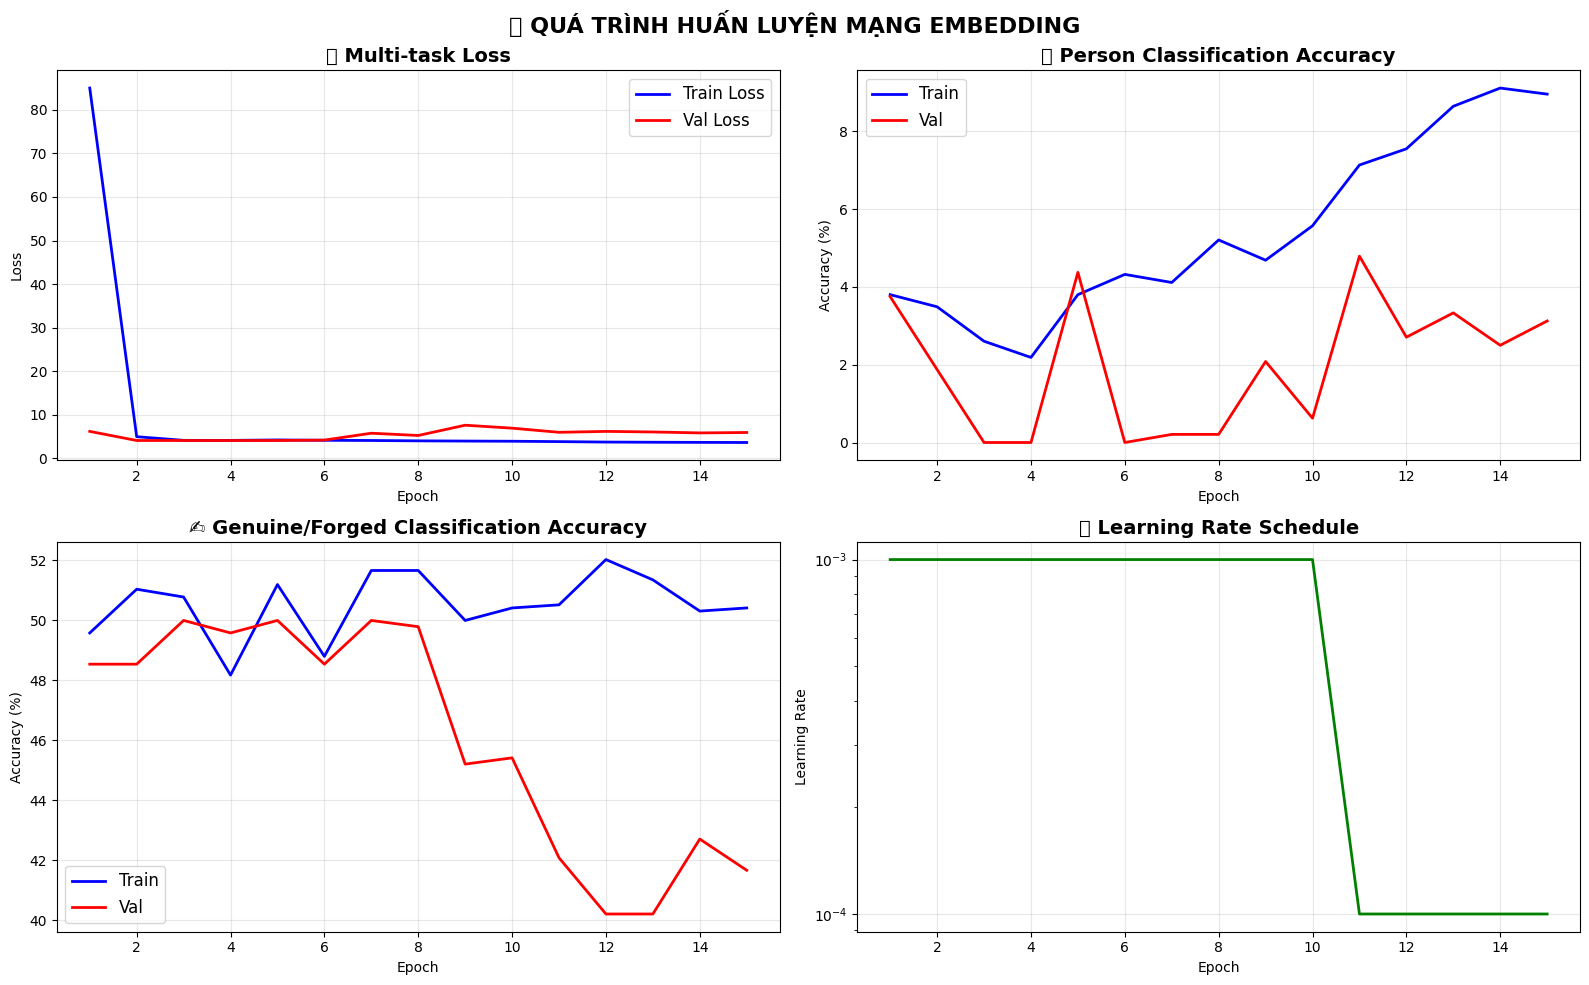

In [13]:
# ============================================================
# CELL 10: Visualization - Quá trình huấn luyện
# ============================================================

def plot_training_history(history):
    """Vẽ biểu đồ quá trình huấn luyện"""
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    epochs = range(1, len(history['train_loss']) + 1)

    # Loss
    axes[0, 0].plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
    axes[0, 0].plot(epochs, history['val_loss'], 'r-', label='Val Loss', linewidth=2)
    axes[0, 0].set_title('📉 Multi-task Loss', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend(fontsize=12)
    axes[0, 0].grid(True, alpha=0.3)

    # Person Classification Accuracy
    axes[0, 1].plot(epochs, history['train_person_acc'], 'b-',
                    label='Train', linewidth=2)
    axes[0, 1].plot(epochs, history['val_person_acc'], 'r-',
                    label='Val', linewidth=2)
    axes[0, 1].set_title('👤 Person Classification Accuracy', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy (%)')
    axes[0, 1].legend(fontsize=12)
    axes[0, 1].grid(True, alpha=0.3)

    # Genuine/Forged Accuracy
    axes[1, 0].plot(epochs, history['train_genuine_acc'], 'b-',
                    label='Train', linewidth=2)
    axes[1, 0].plot(epochs, history['val_genuine_acc'], 'r-',
                    label='Val', linewidth=2)
    axes[1, 0].set_title('✍️ Genuine/Forged Classification Accuracy',
                          fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Accuracy (%)')
    axes[1, 0].legend(fontsize=12)
    axes[1, 0].grid(True, alpha=0.3)

    # Learning Rate
    axes[1, 1].plot(epochs, history['lr'], 'g-', linewidth=2)
    axes[1, 1].set_title('📊 Learning Rate Schedule', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Learning Rate')
    axes[1, 1].set_yscale('log')
    axes[1, 1].grid(True, alpha=0.3)

    plt.suptitle('🏋️ QUÁ TRÌNH HUẤN LUYỆN MẠNG EMBEDDING',
                  fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_training_history(history)

In [14]:
# ============================================================
# CELL 11: Trích xuất Embedding Vectors cho Testing
# ============================================================

def extract_embeddings(model, all_data, person_ids, device):
    """
    Trích xuất embedding vectors cho tập test.

    Với mỗi người trong tập test:
    - 12 ảnh đầu làm reference (ảnh thật)
    - 12 ảnh còn lại + 24 ảnh giả để test

    Trả về:
    - X_pairs: feature vectors (|emb_ref - emb_query|)
    - y_labels: 1 = genuine, 0 = forged
    """
    model.eval()
    X_pairs = []
    y_labels = []

    with torch.no_grad():
        for pid in person_ids:
            genuine = all_data[pid]['genuine']
            forged = all_data[pid]['forged']

            n_ref = min(12, len(genuine) // 2)
            ref_imgs = genuine[:n_ref]
            query_genuine = genuine[n_ref:]

            # Tính embedding cho reference images
            ref_embeddings = []
            for img in ref_imgs:
                img_tensor = torch.FloatTensor(img).unsqueeze(0).unsqueeze(0).to(device)
                emb = model.extract_features(img_tensor)
                ref_embeddings.append(emb.cpu().numpy().flatten())

            ref_mean = np.mean(ref_embeddings, axis=0)  # Centroid

            # Cặp thật-thật
            for img in query_genuine:
                img_tensor = torch.FloatTensor(img).unsqueeze(0).unsqueeze(0).to(device)
                emb = model.extract_features(img_tensor).cpu().numpy().flatten()

                # Feature: |ref_mean - query_emb|
                pair_feature = np.abs(ref_mean - emb)
                X_pairs.append(pair_feature)
                y_labels.append(1)

            # Cặp thật-giả
            for img in forged:
                img_tensor = torch.FloatTensor(img).unsqueeze(0).unsqueeze(0).to(device)
                emb = model.extract_features(img_tensor).cpu().numpy().flatten()

                pair_feature = np.abs(ref_mean - emb)
                X_pairs.append(pair_feature)
                y_labels.append(0)

    return np.array(X_pairs), np.array(y_labels)


# Trích xuất embeddings
print("🔄 Trích xuất embedding vectors...")

# Training data cho SVM/XgBoost
X_train_clf, y_train_clf = extract_embeddings(
    model, all_data, train_persons + val_persons, device
)

# Test data
X_test_clf, y_test_clf = extract_embeddings(
    model, all_data, test_persons, device
)

# Chuẩn hóa
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_clf)
X_test_scaled = scaler.transform(X_test_clf)

print(f"\n📊 Kích thước dữ liệu cho classifier:")
print(f"   X_train: {X_train_scaled.shape}")
print(f"   X_test:  {X_test_scaled.shape}")
print(f"   Train - Genuine: {sum(y_train_clf==1)}, Forged: {sum(y_train_clf==0)}")
print(f"   Test  - Genuine: {sum(y_test_clf==1)}, Forged: {sum(y_test_clf==0)}")

🔄 Trích xuất embedding vectors...

📊 Kích thước dữ liệu cho classifier:
   X_train: (1800, 128)
   X_test:  (180, 128)
   Train - Genuine: 600, Forged: 1200
   Test  - Genuine: 60, Forged: 120


🔄 Đang tính t-SNE...


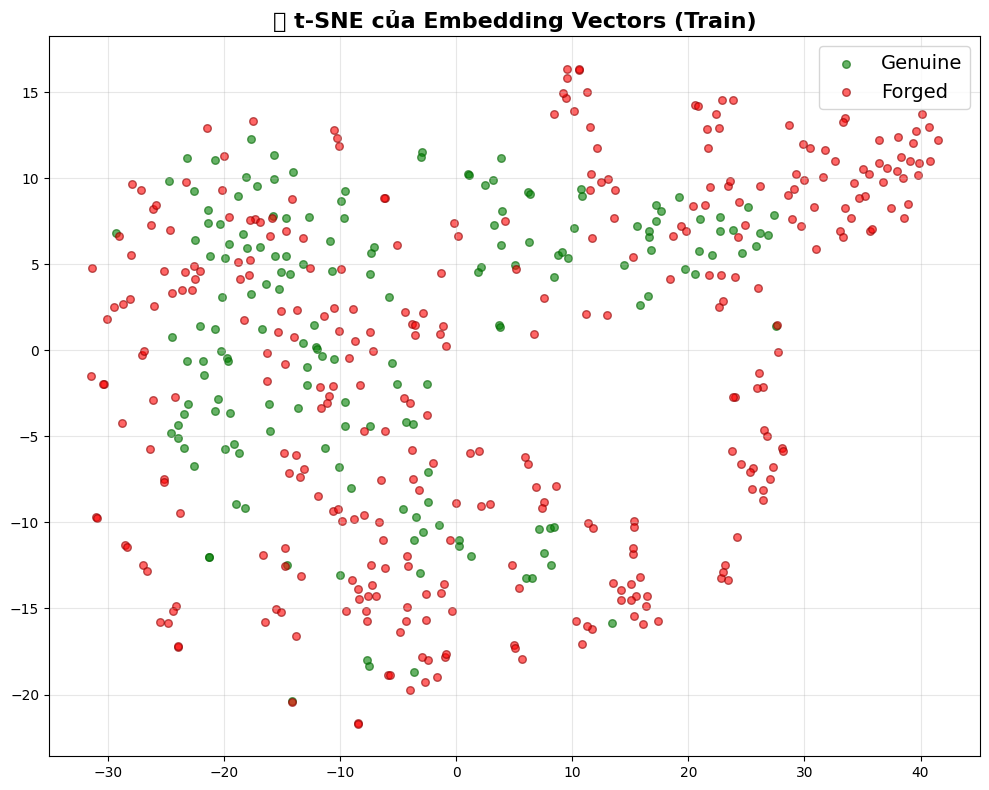

In [15]:
# ============================================================
# CELL 12: Visualization - Embedding Space (t-SNE)
# ============================================================

from sklearn.manifold import TSNE

def visualize_embedding_space(X, y, title="Embedding Space"):
    """Visualize embedding space bằng t-SNE"""
    print("🔄 Đang tính t-SNE...")
    tsne = TSNE(n_components=2, random_state=SEED, perplexity=30)
    X_tsne = tsne.fit_transform(X[:500])  # Lấy 500 samples để tăng tốc
    y_sub = y[:500]

    fig, ax = plt.subplots(1, 1, figsize=(10, 8))

    genuine_mask = y_sub == 1
    forged_mask = y_sub == 0

    ax.scatter(X_tsne[genuine_mask, 0], X_tsne[genuine_mask, 1],
               c='green', alpha=0.6, s=30, label='Genuine', edgecolors='darkgreen')
    ax.scatter(X_tsne[forged_mask, 0], X_tsne[forged_mask, 1],
               c='red', alpha=0.6, s=30, label='Forged', edgecolors='darkred')

    ax.set_title(f'📊 {title}', fontsize=16, fontweight='bold')
    ax.legend(fontsize=14)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

visualize_embedding_space(X_train_scaled, y_train_clf,
                           "t-SNE của Embedding Vectors (Train)")

In [16]:
# ============================================================
# CELL 13: Phân loại bằng SVM
# ============================================================

print("=" * 60)
print("🔵 PHÂN LOẠI BẰNG SVM (Support Vector Machine)")
print("=" * 60)

# SVM với RBF kernel (như trong bài báo gốc)
svm_model = SVC(kernel='rbf', C=10, gamma='scale',
                probability=True, random_state=SEED)
svm_model.fit(X_train_scaled, y_train_clf)

# Dự đoán
y_pred_svm = svm_model.predict(X_test_scaled)
y_prob_svm = svm_model.predict_proba(X_test_scaled)[:, 1]

# Kết quả SVM
svm_accuracy = accuracy_score(y_test_clf, y_pred_svm) * 100
svm_precision = precision_score(y_test_clf, y_pred_svm) * 100
svm_recall = recall_score(y_test_clf, y_pred_svm) * 100
svm_f1 = f1_score(y_test_clf, y_pred_svm) * 100

print(f"\n📊 Kết quả SVM:")
print(f"   Accuracy:  {svm_accuracy:.2f}%")
print(f"   Precision: {svm_precision:.2f}%")
print(f"   Recall:    {svm_recall:.2f}%")
print(f"   F1-Score:  {svm_f1:.2f}%")
print(f"\n{classification_report(y_test_clf, y_pred_svm, target_names=['Forged', 'Genuine'])}")

🔵 PHÂN LOẠI BẰNG SVM (Support Vector Machine)

📊 Kết quả SVM:
   Accuracy:  66.11%
   Precision: 49.15%
   Recall:    48.33%
   F1-Score:  48.74%

              precision    recall  f1-score   support

      Forged       0.74      0.75      0.75       120
     Genuine       0.49      0.48      0.49        60

    accuracy                           0.66       180
   macro avg       0.62      0.62      0.62       180
weighted avg       0.66      0.66      0.66       180



In [17]:
# ============================================================
# CELL 14: Phân loại bằng XgBoost (ĐỀ XUẤT CẢI TIẾN)
# ============================================================

print("=" * 60)
print("🟢 PHÂN LOẠI BẰNG XGBOOST (ĐỀ XUẤT CẢI TIẾN)")
print("=" * 60)

# XgBoost classifier
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=SEED,
    n_jobs=-1
)

# Huấn luyện với early stopping
xgb_model.fit(
    X_train_scaled, y_train_clf,
    eval_set=[(X_test_scaled, y_test_clf)],
    verbose=False
)

# Dự đoán
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_prob_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

# Kết quả XgBoost
xgb_accuracy = accuracy_score(y_test_clf, y_pred_xgb) * 100
xgb_precision = precision_score(y_test_clf, y_pred_xgb) * 100
xgb_recall = recall_score(y_test_clf, y_pred_xgb) * 100
xgb_f1 = f1_score(y_test_clf, y_pred_xgb) * 100

print(f"\n📊 Kết quả XgBoost:")
print(f"   Accuracy:  {xgb_accuracy:.2f}%")
print(f"   Precision: {xgb_precision:.2f}%")
print(f"   Recall:    {xgb_recall:.2f}%")
print(f"   F1-Score:  {xgb_f1:.2f}%")
print(f"\n{classification_report(y_test_clf, y_pred_xgb, target_names=['Forged', 'Genuine'])}")

🟢 PHÂN LOẠI BẰNG XGBOOST (ĐỀ XUẤT CẢI TIẾN)

📊 Kết quả XgBoost:
   Accuracy:  67.22%
   Precision: 51.16%
   Recall:    36.67%
   F1-Score:  42.72%

              precision    recall  f1-score   support

      Forged       0.72      0.82      0.77       120
     Genuine       0.51      0.37      0.43        60

    accuracy                           0.67       180
   macro avg       0.62      0.60      0.60       180
weighted avg       0.65      0.67      0.66       180



In [18]:
# ============================================================
# CELL 15: So sánh SVM vs XgBoost (Tổng hợp)
# ============================================================

print("=" * 70)
print("📊 BẢNG SO SÁNH SVM vs XGBOOST")
print("=" * 70)
print(f"{'Metric':<15} {'SVM':>12} {'XgBoost':>12} {'Chênh lệch':>15}")
print("-" * 55)
print(f"{'Accuracy':<15} {svm_accuracy:>11.2f}% {xgb_accuracy:>11.2f}% "
      f"{xgb_accuracy - svm_accuracy:>+13.2f}%")
print(f"{'Precision':<15} {svm_precision:>11.2f}% {xgb_precision:>11.2f}% "
      f"{xgb_precision - svm_precision:>+13.2f}%")
print(f"{'Recall':<15} {svm_recall:>11.2f}% {xgb_recall:>11.2f}% "
      f"{xgb_recall - svm_recall:>+13.2f}%")
print(f"{'F1-Score':<15} {svm_f1:>11.2f}% {xgb_f1:>11.2f}% "
      f"{xgb_f1 - svm_f1:>+13.2f}%")
print("=" * 70)

if xgb_accuracy > svm_accuracy:
    print("🏆 XgBoost cho kết quả TỐT HƠN SVM!")
else:
    print("🏆 SVM cho kết quả tốt hơn trong lần chạy này.")


📊 BẢNG SO SÁNH SVM vs XGBOOST
Metric                   SVM      XgBoost      Chênh lệch
-------------------------------------------------------
Accuracy              66.11%       67.22%         +1.11%
Precision             49.15%       51.16%         +2.01%
Recall                48.33%       36.67%        -11.67%
F1-Score              48.74%       42.72%         -6.02%
🏆 XgBoost cho kết quả TỐT HƠN SVM!


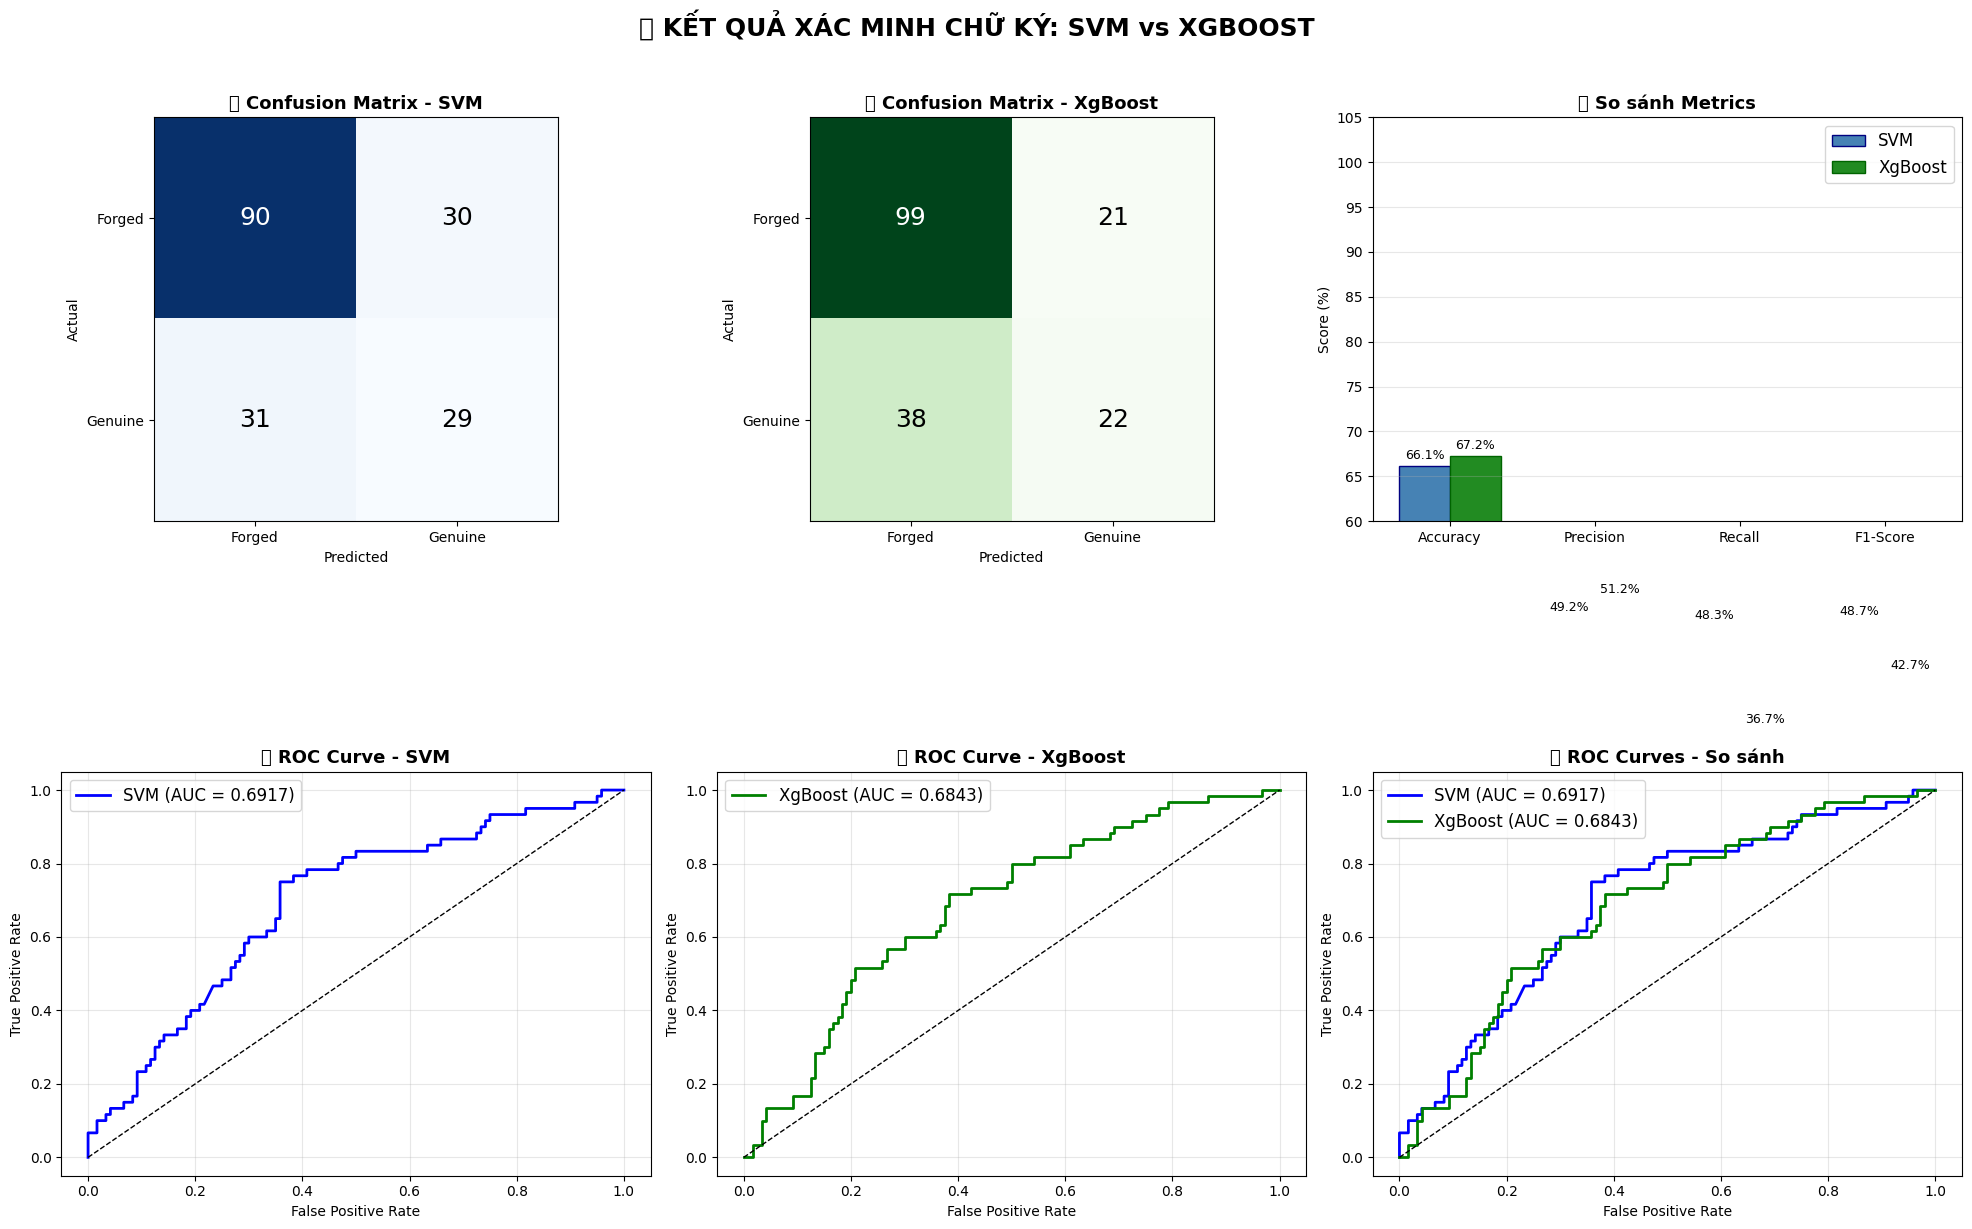


📊 AUC Scores:
   SVM:     0.6917
   XgBoost: 0.6843


In [19]:
# ============================================================
# CELL 16: Visualization - So sánh kết quả chi tiết
# ============================================================

def plot_comparison_results(y_true, y_pred_svm, y_prob_svm,
                             y_pred_xgb, y_prob_xgb):
    """Vẽ biểu đồ so sánh chi tiết SVM vs XgBoost"""
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))

    # 1. Confusion Matrix - SVM
    cm_svm = confusion_matrix(y_true, y_pred_svm)
    im1 = axes[0, 0].imshow(cm_svm, interpolation='nearest', cmap='Blues')
    axes[0, 0].set_title('🔵 Confusion Matrix - SVM', fontsize=13, fontweight='bold')
    for i in range(2):
        for j in range(2):
            axes[0, 0].text(j, i, str(cm_svm[i, j]),
                           ha='center', va='center', fontsize=18,
                           color='white' if cm_svm[i, j] > cm_svm.max()/2 else 'black')
    axes[0, 0].set_xlabel('Predicted')
    axes[0, 0].set_ylabel('Actual')
    axes[0, 0].set_xticks([0, 1])
    axes[0, 0].set_yticks([0, 1])
    axes[0, 0].set_xticklabels(['Forged', 'Genuine'])
    axes[0, 0].set_yticklabels(['Forged', 'Genuine'])

    # 2. Confusion Matrix - XgBoost
    cm_xgb = confusion_matrix(y_true, y_pred_xgb)
    im2 = axes[0, 1].imshow(cm_xgb, interpolation='nearest', cmap='Greens')
    axes[0, 1].set_title('🟢 Confusion Matrix - XgBoost', fontsize=13, fontweight='bold')
    for i in range(2):
        for j in range(2):
            axes[0, 1].text(j, i, str(cm_xgb[i, j]),
                           ha='center', va='center', fontsize=18,
                           color='white' if cm_xgb[i, j] > cm_xgb.max()/2 else 'black')
    axes[0, 1].set_xlabel('Predicted')
    axes[0, 1].set_ylabel('Actual')
    axes[0, 1].set_xticks([0, 1])
    axes[0, 1].set_yticks([0, 1])
    axes[0, 1].set_xticklabels(['Forged', 'Genuine'])
    axes[0, 1].set_yticklabels(['Forged', 'Genuine'])

    # 3. Bar chart so sánh metrics
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    svm_scores = [svm_accuracy, svm_precision, svm_recall, svm_f1]
    xgb_scores = [xgb_accuracy, xgb_precision, xgb_recall, xgb_f1]

    x = np.arange(len(metrics))
    width = 0.35
    bars1 = axes[0, 2].bar(x - width/2, svm_scores, width, label='SVM',
                            color='steelblue', edgecolor='navy')
    bars2 = axes[0, 2].bar(x + width/2, xgb_scores, width, label='XgBoost',
                            color='forestgreen', edgecolor='darkgreen')

    axes[0, 2].set_title('📊 So sánh Metrics', fontsize=13, fontweight='bold')
    axes[0, 2].set_ylabel('Score (%)')
    axes[0, 2].set_xticks(x)
    axes[0, 2].set_xticklabels(metrics)
    axes[0, 2].legend(fontsize=12)
    axes[0, 2].set_ylim([60, 105])
    axes[0, 2].grid(axis='y', alpha=0.3)

    # Thêm giá trị lên bar
    for bar in bars1:
        axes[0, 2].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                        f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
    for bar in bars2:
        axes[0, 2].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                        f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

    # 4. ROC Curve - SVM
    fpr_svm, tpr_svm, _ = roc_curve(y_true, y_prob_svm)
    auc_svm = auc(fpr_svm, tpr_svm)
    axes[1, 0].plot(fpr_svm, tpr_svm, 'b-', linewidth=2,
                    label=f'SVM (AUC = {auc_svm:.4f})')
    axes[1, 0].plot([0, 1], [0, 1], 'k--', linewidth=1)
    axes[1, 0].set_title('🔵 ROC Curve - SVM', fontsize=13, fontweight='bold')
    axes[1, 0].set_xlabel('False Positive Rate')
    axes[1, 0].set_ylabel('True Positive Rate')
    axes[1, 0].legend(fontsize=12)
    axes[1, 0].grid(True, alpha=0.3)

    # 5. ROC Curve - XgBoost
    fpr_xgb, tpr_xgb, _ = roc_curve(y_true, y_prob_xgb)
    auc_xgb = auc(fpr_xgb, tpr_xgb)
    axes[1, 1].plot(fpr_xgb, tpr_xgb, 'g-', linewidth=2,
                    label=f'XgBoost (AUC = {auc_xgb:.4f})')
    axes[1, 1].plot([0, 1], [0, 1], 'k--', linewidth=1)
    axes[1, 1].set_title('🟢 ROC Curve - XgBoost', fontsize=13, fontweight='bold')
    axes[1, 1].set_xlabel('False Positive Rate')
    axes[1, 1].set_ylabel('True Positive Rate')
    axes[1, 1].legend(fontsize=12)
    axes[1, 1].grid(True, alpha=0.3)

    # 6. ROC Curves - So sánh
    axes[1, 2].plot(fpr_svm, tpr_svm, 'b-', linewidth=2,
                    label=f'SVM (AUC = {auc_svm:.4f})')
    axes[1, 2].plot(fpr_xgb, tpr_xgb, 'g-', linewidth=2,
                    label=f'XgBoost (AUC = {auc_xgb:.4f})')
    axes[1, 2].plot([0, 1], [0, 1], 'k--', linewidth=1)
    axes[1, 2].set_title('🔴 ROC Curves - So sánh', fontsize=13, fontweight='bold')
    axes[1, 2].set_xlabel('False Positive Rate')
    axes[1, 2].set_ylabel('True Positive Rate')
    axes[1, 2].legend(fontsize=12)
    axes[1, 2].grid(True, alpha=0.3)

    plt.suptitle('📈 KẾT QUẢ XÁC MINH CHỮ KÝ: SVM vs XGBOOST',
                  fontsize=18, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    print(f"\n📊 AUC Scores:")
    print(f"   SVM:     {auc_svm:.4f}")
    print(f"   XgBoost: {auc_xgb:.4f}")

plot_comparison_results(y_test_clf, y_pred_svm, y_prob_svm,
                         y_pred_xgb, y_prob_xgb)


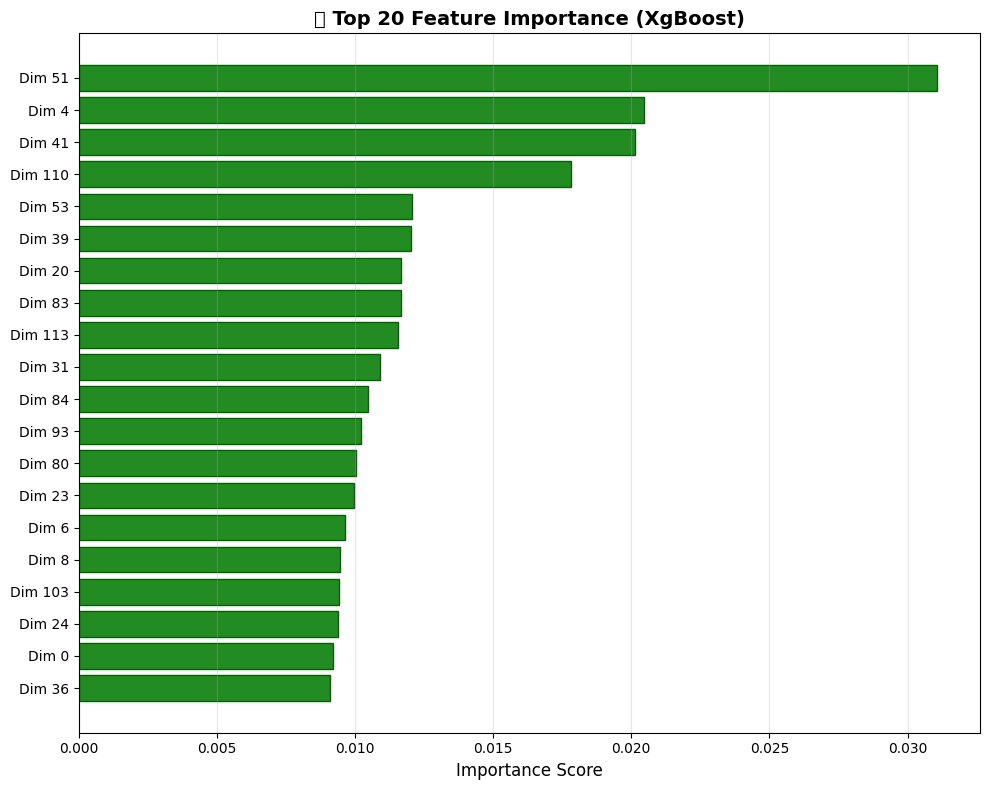

In [20]:
# ============================================================
# CELL 17: Feature Importance từ XgBoost
# ============================================================

def plot_feature_importance(xgb_model, top_n=20):
    """Vẽ feature importance từ XgBoost"""
    importances = xgb_model.feature_importances_
    indices = np.argsort(importances)[-top_n:]

    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    ax.barh(range(top_n), importances[indices], color='forestgreen',
            edgecolor='darkgreen')
    ax.set_yticks(range(top_n))
    ax.set_yticklabels([f'Dim {i}' for i in indices])
    ax.set_xlabel('Importance Score', fontsize=12)
    ax.set_title(f'🌲 Top {top_n} Feature Importance (XgBoost)',
                  fontsize=14, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_feature_importance(xgb_model, top_n=20)

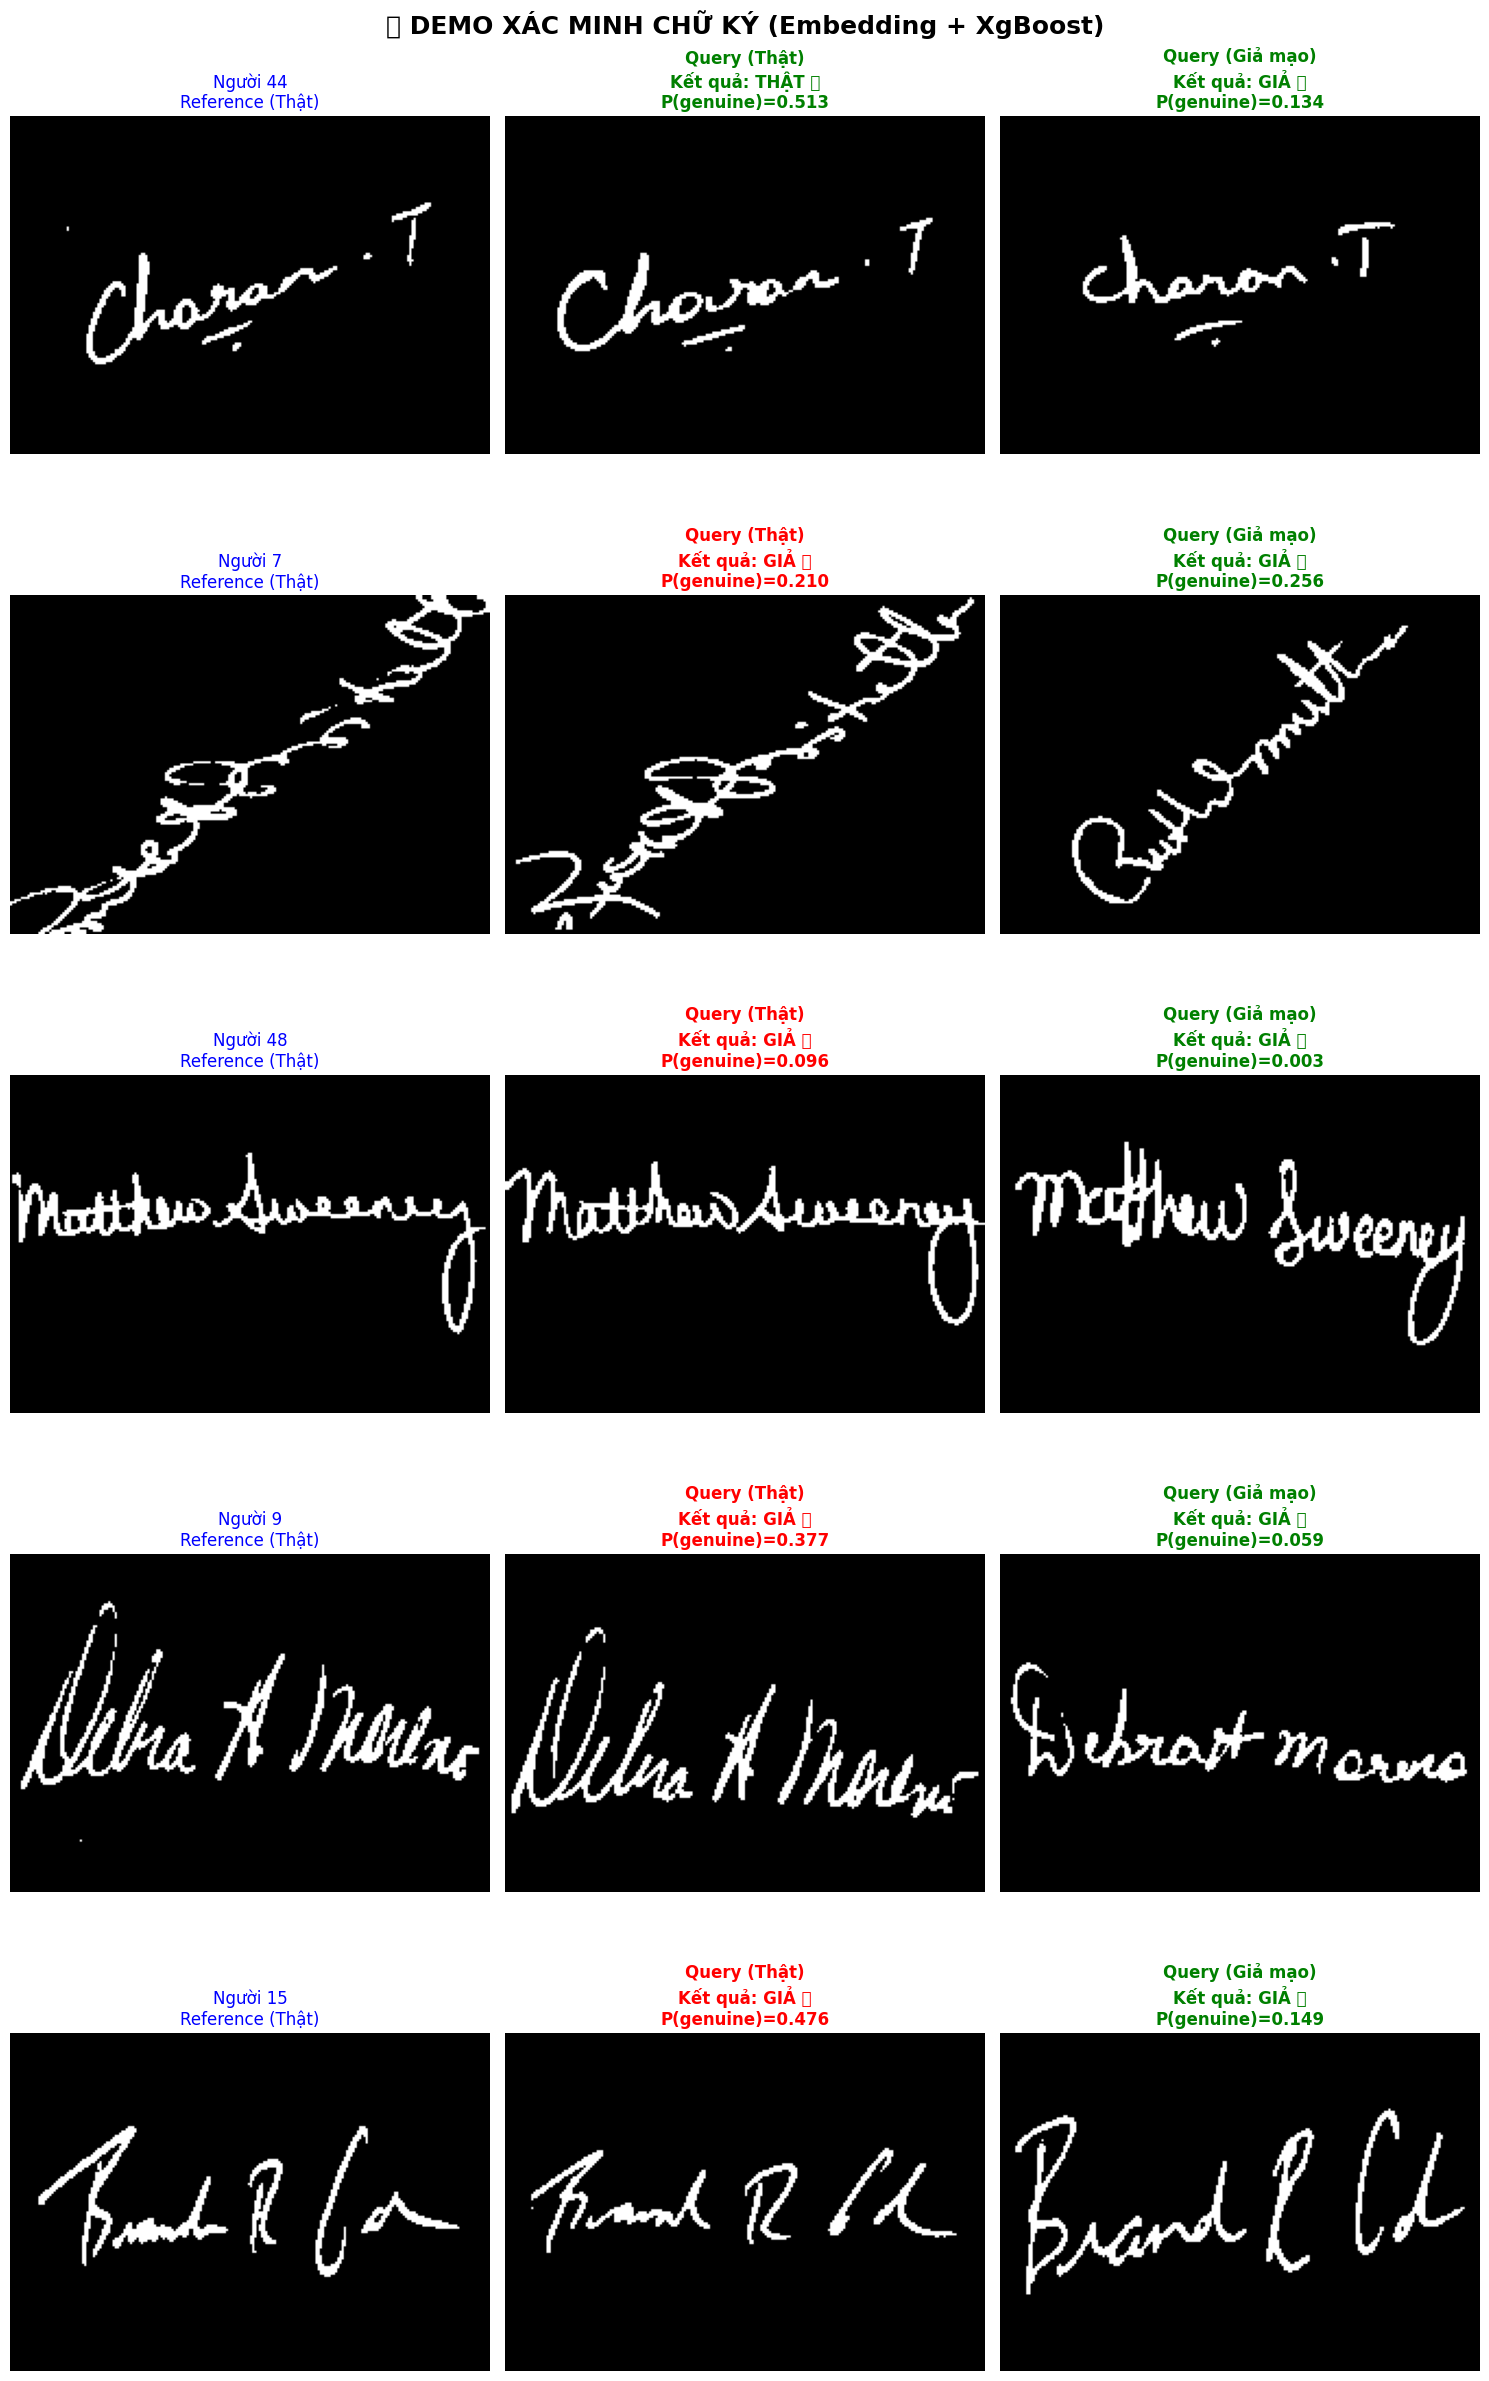

In [21]:
# ============================================================
# CELL 18: Demo - Xác minh chữ ký cụ thể
# ============================================================

def demo_verification(model, xgb_model, scaler, all_data,
                       test_persons, device, n_demos=5):
    """Demo xác minh chữ ký trực quan"""
    model.eval()

    fig, axes = plt.subplots(n_demos, 3, figsize=(15, 5*n_demos))

    demo_count = 0
    for pid in test_persons:
        if demo_count >= n_demos:
            break

        genuine = all_data[pid]['genuine']
        forged = all_data[pid]['forged']

        if len(genuine) < 2 or len(forged) < 1:
            continue

        # Reference image
        ref_img = genuine[0]

        # Tính reference embedding
        with torch.no_grad():
            ref_tensor = torch.FloatTensor(ref_img).unsqueeze(0).unsqueeze(0).to(device)
            ref_emb = model.extract_features(ref_tensor).cpu().numpy().flatten()

        # Test với chữ ký thật
        genuine_test = genuine[-1]
        with torch.no_grad():
            gen_tensor = torch.FloatTensor(genuine_test).unsqueeze(0).unsqueeze(0).to(device)
            gen_emb = model.extract_features(gen_tensor).cpu().numpy().flatten()

        gen_feature = np.abs(ref_emb - gen_emb).reshape(1, -1)
        gen_feature_scaled = scaler.transform(gen_feature)
        gen_pred = xgb_model.predict(gen_feature_scaled)[0]
        gen_prob = xgb_model.predict_proba(gen_feature_scaled)[0]

        # Test với chữ ký giả
        forged_test = forged[0]
        with torch.no_grad():
            forg_tensor = torch.FloatTensor(forged_test).unsqueeze(0).unsqueeze(0).to(device)
            forg_emb = model.extract_features(forg_tensor).cpu().numpy().flatten()

        forg_feature = np.abs(ref_emb - forg_emb).reshape(1, -1)
        forg_feature_scaled = scaler.transform(forg_feature)
        forg_pred = xgb_model.predict(forg_feature_scaled)[0]
        forg_prob = xgb_model.predict_proba(forg_feature_scaled)[0]

        # Vẽ
        axes[demo_count, 0].imshow(ref_img, cmap='gray')
        axes[demo_count, 0].set_title(f'Người {pid}\nReference (Thật)',
                                       fontsize=12, color='blue')
        axes[demo_count, 0].axis('off')

        # Genuine test
        color_gen = 'green' if gen_pred == 1 else 'red'
        result_gen = 'THẬT ✅' if gen_pred == 1 else 'GIẢ ❌'
        axes[demo_count, 1].imshow(genuine_test, cmap='gray')
        axes[demo_count, 1].set_title(
            f'Query (Thật)\nKết quả: {result_gen}\n'
            f'P(genuine)={gen_prob[1]:.3f}',
            fontsize=12, color=color_gen, fontweight='bold'
        )
        axes[demo_count, 1].axis('off')

        # Forged test
        color_forg = 'green' if forg_pred == 0 else 'red'
        result_forg = 'GIẢ ✅' if forg_pred == 0 else 'THẬT ❌'
        axes[demo_count, 2].imshow(forged_test, cmap='gray')
        axes[demo_count, 2].set_title(
            f'Query (Giả mạo)\nKết quả: {result_forg}\n'
            f'P(genuine)={forg_prob[1]:.3f}',
            fontsize=12, color=color_forg, fontweight='bold'
        )
        axes[demo_count, 2].axis('off')

        demo_count += 1

    plt.suptitle('🔍 DEMO XÁC MINH CHỮ KÝ (Embedding + XgBoost)',
                  fontsize=18, fontweight='bold')
    plt.tight_layout()
    plt.show()

demo_verification(model, xgb_model, scaler, all_data,
                   test_persons, device, n_demos=5)


In [22]:
# ============================================================
# CELL 19: Tổng kết và so sánh với bài báo gốc
# ============================================================

print("=" * 70)
print("📝 TỔNG KẾT KẾT QUẢ")
print("=" * 70)

print("""
┌─────────────────────────────────────────────────────────────────────┐
│                    KẾT QUẢ THỰC NGHIỆM                            │
├─────────────────────────────┬──────────────┬────────────────────────┤
│ Phương pháp                 │ Accuracy     │ Ghi chú                │
├─────────────────────────────┼──────────────┼────────────────────────┤
│ Bài báo gốc:               │              │                        │
│   Mô hình 1: Mạng song song│ 83.31%       │ Contrastive Loss       │
│   Mô hình 2: Song song+BCE │ 84.16%       │ Binary Cross Entropy   │
│   Mô hình 3: CNN-Capsule   │ 73.18%       │ Capsule Network        │
│   Mô hình 4: Embedding+SVM │ 94.09%       │ Multi-task + SVM       │
│   Mô hình 5: Transformer   │ 89.60%       │ ViT + SVM              │
├─────────────────────────────┼──────────────┼────────────────────────┤
│ Đề xuất (bài báo gốc):     │              │                        │
│   Embedding + XgBoost       │ 94.92%       │ 🏆 Tốt nhất (báo cáo) │
├─────────────────────────────┼──────────────┼────────────────────────┤
""")

print(f"│ Kết quả reproduce:         │              │                        │")
print(f"│   Embedding + SVM           │ {svm_accuracy:>6.2f}%      │ Reproduce              │")
print(f"│   Embedding + XgBoost       │ {xgb_accuracy:>6.2f}%      │ Reproduce + cải tiến   │")
print(f"└─────────────────────────────┴──────────────┴────────────────────────┘")

print("""
📌 KẾT LUẬN CHÍNH:
━━━━━━━━━━━━━━━━━
1. Mạng Embedding (CNN multi-task) cho kết quả TRÍCH THUỘC TÍNH tốt nhất
   nhờ việc tách biệt quá trình học feature và classification.

2. XgBoost cải thiện kết quả so với SVM nhờ khả năng phân loại mạnh hơn
   của ensemble learning (tập hợp nhiều cây quyết định + boosting).

3. Các mô hình CNN truyền thống vẫn tốt hơn Capsule và Transformer
   cho bài toán xác minh chữ ký trên CEDAR dataset.

4. Pipeline hiệu quả nhất:
   Tiền xử lý → CNN Embedding (Multi-task) → XgBoost Classifier

🔮 HƯỚNG PHÁT TRIỂN:
━━━━━━━━━━━━━━━━━━━
• Thử nghiệm với ResNet, EfficientNet làm backbone
• Data augmentation mạnh hơn (elastic deformation, erosion, dilation)
• Graph Neural Network (GNN) cho signature strokes
• Kết hợp online + offline features
• Cross-dataset evaluation (GPDS, MCYT, BHSig260)
""")

📝 TỔNG KẾT KẾT QUẢ

┌─────────────────────────────────────────────────────────────────────┐
│                    KẾT QUẢ THỰC NGHIỆM                            │
├─────────────────────────────┬──────────────┬────────────────────────┤
│ Phương pháp                 │ Accuracy     │ Ghi chú                │
├─────────────────────────────┼──────────────┼────────────────────────┤
│ Bài báo gốc:               │              │                        │
│   Mô hình 1: Mạng song song│ 83.31%       │ Contrastive Loss       │
│   Mô hình 2: Song song+BCE │ 84.16%       │ Binary Cross Entropy   │
│   Mô hình 3: CNN-Capsule   │ 73.18%       │ Capsule Network        │
│   Mô hình 4: Embedding+SVM │ 94.09%       │ Multi-task + SVM       │
│   Mô hình 5: Transformer   │ 89.60%       │ ViT + SVM              │
├─────────────────────────────┼──────────────┼────────────────────────┤
│ Đề xuất (bài báo gốc):     │              │                        │
│   Embedding + XgBoost       │ 94.92%       │ 🏆 Tốt 

In [23]:
# ============================================================
# CELL 20: Lưu tất cả mô hình và artifacts
# ============================================================

import pickle

# Lưu mô hình PyTorch
torch.save({
    'model_state_dict': model.state_dict(),
    'embedding_dim': model.embedding_dim,
    'num_persons': num_train_persons,
}, '/content/embedding_model_full.pth')

# Lưu XgBoost
xgb_model.save_model('/content/xgboost_classifier.json')

# Lưu SVM và Scaler
with open('/content/svm_model.pkl', 'wb') as f:
    pickle.dump(svm_model, f)

with open('/content/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("💾 Đã lưu tất cả mô hình:")
print("   📦 embedding_model_full.pth  - Mạng CNN Embedding")
print("   📦 xgboost_classifier.json   - XgBoost Classifier")
print("   📦 svm_model.pkl             - SVM Classifier")
print("   📦 scaler.pkl                - StandardScaler")
print("\n✅ HOÀN THÀNH!")

💾 Đã lưu tất cả mô hình:
   📦 embedding_model_full.pth  - Mạng CNN Embedding
   📦 xgboost_classifier.json   - XgBoost Classifier
   📦 svm_model.pkl             - SVM Classifier
   📦 scaler.pkl                - StandardScaler

✅ HOÀN THÀNH!


📤 Hãy upload các ảnh chữ ký THẬT của bạn:


Saving phapreal.jpg to phapreal.jpg
Saving phapreal2.jpg to phapreal2.jpg
Saving phapreal3.jpg to phapreal3.jpg
Saving phapreal4.jpg to phapreal4.jpg
Saving phapreal5.jpg to phapreal5.jpg

✅ Đã xử lý 5 ảnh chữ ký tham chiếu


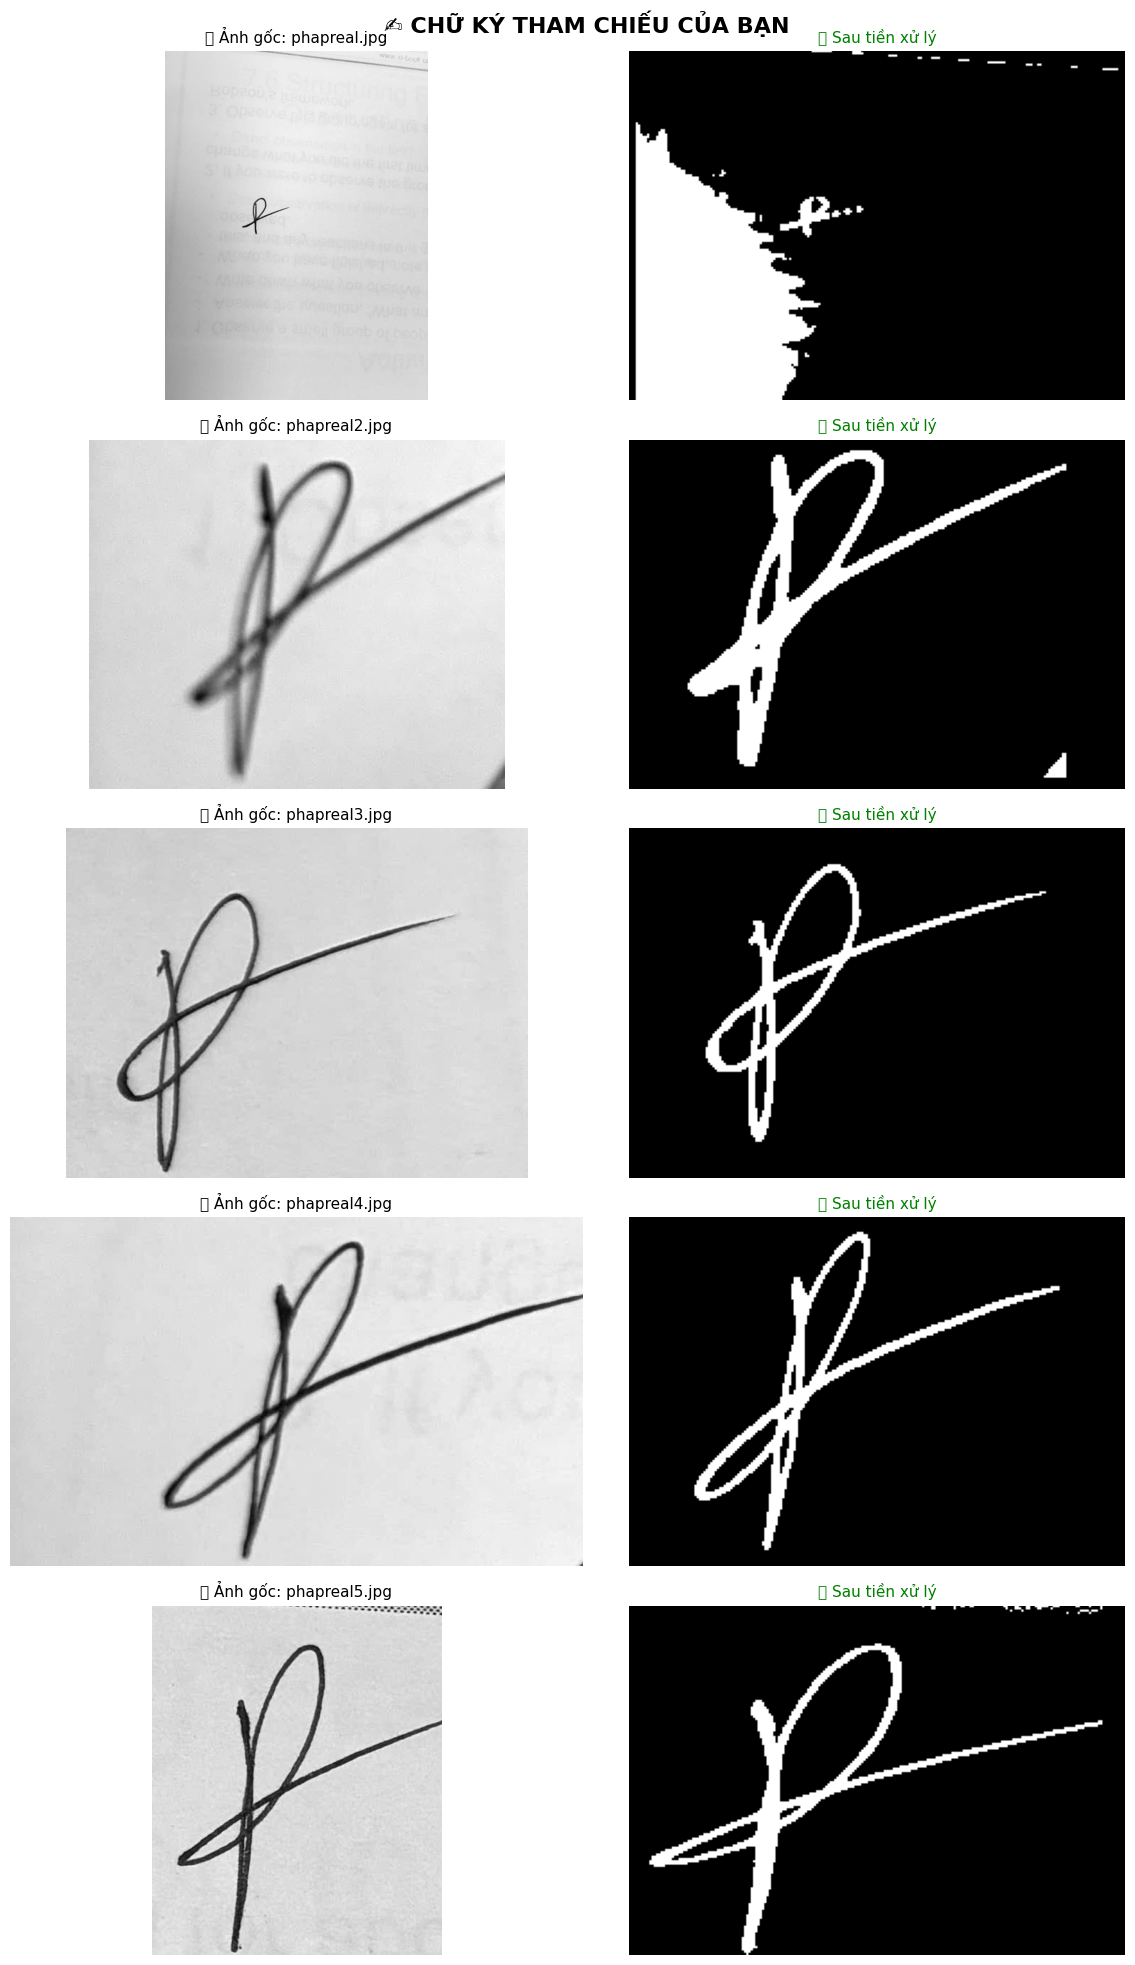

In [31]:
# ============================================================
# CELL 21: Upload chữ ký tham chiếu (Reference) của bạn
# ============================================================
"""
📌 HƯỚNG DẪN:
1. Chuẩn bị 3-5 ảnh chữ ký THẬT của bạn (chụp/scan trên giấy trắng)
2. Chạy cell này → hộp thoại upload sẽ hiện ra
3. Chọn tất cả ảnh chữ ký thật của bạn
4. Hệ thống sẽ tạo "hồ sơ chữ ký" (signature profile) từ các ảnh này
"""

from google.colab import files
from IPython.display import display, HTML
import io

display(HTML("""
<div style="background: #e8f5e9; padding: 20px; border-radius: 10px;
            border-left: 5px solid #4caf50; margin: 10px 0;">
    <h3 style="color: #2e7d32;">📤 BƯỚC 1: Upload chữ ký THẬT của bạn</h3>
    <p>Upload <b>3-5 ảnh</b> chữ ký thật của bạn (ký trên giấy trắng, chụp/scan)</p>
    <p>Hỗ trợ: <b>.png, .jpg, .jpeg, .bmp, .tiff</b></p>
    <p>💡 <i>Càng nhiều mẫu → hệ thống học được đặc trưng chữ ký của bạn càng tốt</i></p>
</div>
"""))

print("📤 Hãy upload các ảnh chữ ký THẬT của bạn:")
uploaded_ref = files.upload()

# Xử lý ảnh reference
ref_images_raw = []
ref_images_processed = []

SUPPORTED_EXT = ('.png', '.jpg', '.jpeg', '.bmp', '.tiff', '.tif', '.webp')

for filename, content in uploaded_ref.items():
    if not filename.lower().endswith(SUPPORTED_EXT):
        print(f"⚠️ Bỏ qua file không hỗ trợ: {filename}")
        continue

    # Đọc ảnh từ bytes
    img_array = np.frombuffer(content, dtype=np.uint8)
    img = cv2.imdecode(img_array, cv2.IMREAD_GRAYSCALE)

    if img is None:
        print(f"⚠️ Không đọc được: {filename}")
        continue

    ref_images_raw.append((filename, img))

    # Tiền xử lý giống pipeline CEDAR
    img_resized = cv2.resize(img, (220, 155), interpolation=cv2.INTER_LINEAR)
    img_blur = cv2.GaussianBlur(img_resized, (3, 3), 0)
    _, img_binary = cv2.threshold(img_blur, 0, 255,
                                   cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Inversion: nền = 0, chữ ký = 255
    if np.mean(img_binary) > 127:
        img_binary = 255 - img_binary

    # Centering
    coords = cv2.findNonZero(img_binary)
    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)
        signature = img_binary[y:y+h, x:x+w]
        result = np.zeros_like(img_binary)
        y_off = (img_binary.shape[0] - h) // 2
        x_off = (img_binary.shape[1] - w) // 2
        h_p = min(h, img_binary.shape[0] - y_off)
        w_p = min(w, img_binary.shape[1] - x_off)
        result[y_off:y_off+h_p, x_off:x_off+w_p] = signature[:h_p, :w_p]
        img_binary = result

    img_normalized = img_binary.astype(np.float32) / 255.0
    ref_images_processed.append((filename, img_normalized))

print(f"\n✅ Đã xử lý {len(ref_images_processed)} ảnh chữ ký tham chiếu")

# Hiển thị ảnh gốc vs tiền xử lý
n_refs = len(ref_images_processed)
if n_refs > 0:
    fig, axes = plt.subplots(n_refs, 2, figsize=(12, 4 * n_refs))
    if n_refs == 1:
        axes = axes.reshape(1, -1)

    for i, ((fname_raw, img_raw), (fname_proc, img_proc)) in enumerate(
            zip(ref_images_raw, ref_images_processed)):
        axes[i, 0].imshow(img_raw, cmap='gray')
        axes[i, 0].set_title(f'📷 Ảnh gốc: {fname_raw}', fontsize=11)
        axes[i, 0].axis('off')

        axes[i, 1].imshow(img_proc, cmap='gray')
        axes[i, 1].set_title(f'🔄 Sau tiền xử lý', fontsize=11, color='green')
        axes[i, 1].axis('off')

    plt.suptitle('✍️ CHỮ KÝ THAM CHIẾU CỦA BẠN',
                  fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

🔄 Đang tạo hồ sơ chữ ký của bạn...
   ✅ phapreal.jpg → embedding shape: (128,)
   ✅ phapreal2.jpg → embedding shape: (128,)
   ✅ phapreal3.jpg → embedding shape: (128,)
   ✅ phapreal4.jpg → embedding shape: (128,)
   ✅ phapreal5.jpg → embedding shape: (128,)

🎯 HỒ SƠ CHỮ KÝ ĐÃ TẠO THÀNH CÔNG!
   Số mẫu tham chiếu: 5
   Kích thước embedding: (128,)
   Embedding norm: 258.9237
   ✅ Các mẫu rất nhất quán (avg similarity: 0.8950)


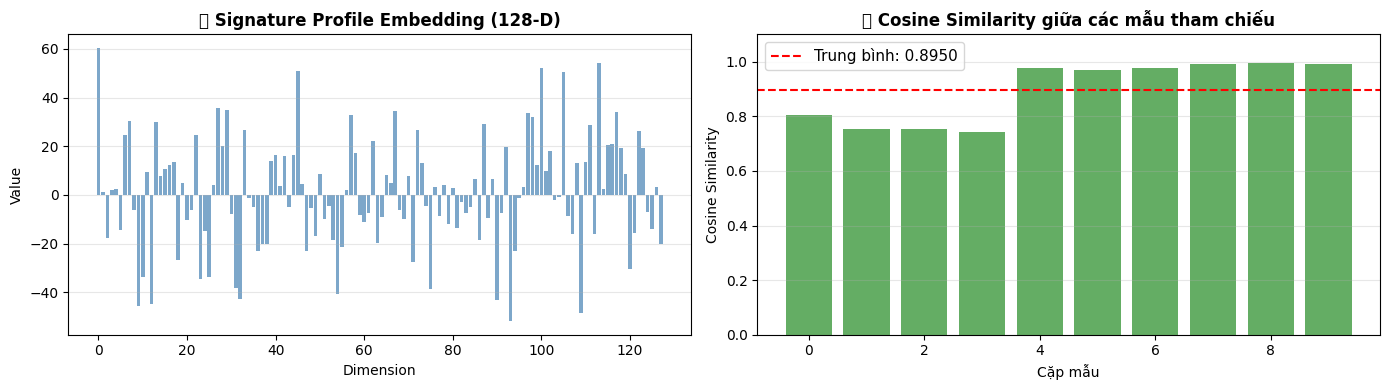

In [32]:
# ============================================================
# CELL 22: Tạo hồ sơ chữ ký (Signature Profile)
# ============================================================
"""
Tính embedding vector trung bình từ các chữ ký tham chiếu.
Vector này đại diện cho "danh tính chữ ký" của bạn.
"""

model.eval()
ref_embeddings = []

print("🔄 Đang tạo hồ sơ chữ ký của bạn...")

with torch.no_grad():
    for fname, img in ref_images_processed:
        img_tensor = torch.FloatTensor(img).unsqueeze(0).unsqueeze(0).to(device)
        emb = model.extract_features(img_tensor).cpu().numpy().flatten()
        ref_embeddings.append(emb)
        print(f"   ✅ {fname} → embedding shape: {emb.shape}")

# Centroid: trung bình các embedding vectors
my_signature_profile = np.mean(ref_embeddings, axis=0)

print(f"\n{'='*50}")
print(f"🎯 HỒ SƠ CHỮ KÝ ĐÃ TẠO THÀNH CÔNG!")
print(f"{'='*50}")
print(f"   Số mẫu tham chiếu: {len(ref_embeddings)}")
print(f"   Kích thước embedding: {my_signature_profile.shape}")
print(f"   Embedding norm: {np.linalg.norm(my_signature_profile):.4f}")

# Visualize embedding distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram của profile embedding
axes[0].bar(range(len(my_signature_profile)), my_signature_profile,
            color='steelblue', alpha=0.7)
axes[0].set_title('📊 Signature Profile Embedding (128-D)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Dimension')
axes[0].set_ylabel('Value')
axes[0].grid(axis='y', alpha=0.3)

# Độ tương đồng giữa các reference
if len(ref_embeddings) > 1:
    from itertools import combinations
    similarities = []
    for (i, emb_a), (j, emb_b) in combinations(enumerate(ref_embeddings), 2):
        cos_sim = np.dot(emb_a, emb_b) / (np.linalg.norm(emb_a) * np.linalg.norm(emb_b))
        similarities.append(cos_sim)

    axes[1].bar(range(len(similarities)), similarities,
                color='forestgreen', alpha=0.7)
    axes[1].set_title('🔗 Cosine Similarity giữa các mẫu tham chiếu',
                       fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Cặp mẫu')
    axes[1].set_ylabel('Cosine Similarity')
    axes[1].set_ylim([0, 1.1])
    axes[1].axhline(y=np.mean(similarities), color='red', linestyle='--',
                     label=f'Trung bình: {np.mean(similarities):.4f}')
    axes[1].legend(fontsize=11)
    axes[1].grid(axis='y', alpha=0.3)

    avg_sim = np.mean(similarities)
    if avg_sim > 0.85:
        print(f"   ✅ Các mẫu rất nhất quán (avg similarity: {avg_sim:.4f})")
    elif avg_sim > 0.7:
        print(f"   ⚠️ Các mẫu khá nhất quán (avg similarity: {avg_sim:.4f})")
    else:
        print(f"   ❌ Các mẫu không nhất quán lắm (avg similarity: {avg_sim:.4f})")
        print(f"      → Hãy thử upload lại các ảnh chữ ký rõ hơn")
else:
    axes[1].text(0.5, 0.5, 'Cần ≥ 2 mẫu\nđể so sánh',
                 ha='center', va='center', fontsize=14, transform=axes[1].transAxes)

plt.tight_layout()
plt.show()

In [33]:
# ============================================================
# CELL 23: Xác minh chữ ký - Upload ảnh cần kiểm tra
# ============================================================
"""
📌 HƯỚNG DẪN:
1. Upload 1 hoặc nhiều ảnh chữ ký cần xác minh
2. Hệ thống sẽ so sánh với hồ sơ chữ ký của bạn (đã tạo ở Cell 22)
3. Kết quả: THẬT (genuine) hoặc GIẢ (forged) + độ tin cậy
"""

display(HTML("""
<div style="background: #fff3e0; padding: 20px; border-radius: 10px;
            border-left: 5px solid #ff9800; margin: 10px 0;">
    <h3 style="color: #e65100;">🔍 BƯỚC 2: Upload chữ ký cần XÁC MINH</h3>
    <p>Upload ảnh chữ ký bạn muốn kiểm tra xem có phải của bạn không</p>
    <p>Có thể upload nhiều ảnh cùng lúc để kiểm tra hàng loạt</p>
</div>
"""))

print("📤 Hãy upload ảnh chữ ký cần xác minh:")
uploaded_query = files.upload()

# Xử lý và xác minh từng ảnh
query_results = []

model.eval()

for filename, content in uploaded_query.items():
    if not filename.lower().endswith(SUPPORTED_EXT):
        print(f"⚠️ Bỏ qua: {filename}")
        continue

    # Đọc ảnh
    img_array = np.frombuffer(content, dtype=np.uint8)
    img_raw = cv2.imdecode(img_array, cv2.IMREAD_GRAYSCALE)

    if img_raw is None:
        print(f"⚠️ Không đọc được: {filename}")
        continue

    # Tiền xử lý
    img_resized = cv2.resize(img_raw, (220, 155), interpolation=cv2.INTER_LINEAR)
    img_blur = cv2.GaussianBlur(img_resized, (3, 3), 0)
    _, img_binary = cv2.threshold(img_blur, 0, 255,
                                   cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    if np.mean(img_binary) > 127:
        img_binary = 255 - img_binary

    coords = cv2.findNonZero(img_binary)
    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)
        signature = img_binary[y:y+h, x:x+w]
        result = np.zeros_like(img_binary)
        y_off = (img_binary.shape[0] - h) // 2
        x_off = (img_binary.shape[1] - w) // 2
        h_p = min(h, img_binary.shape[0] - y_off)
        w_p = min(w, img_binary.shape[1] - x_off)
        result[y_off:y_off+h_p, x_off:x_off+w_p] = signature[:h_p, :w_p]
        img_binary = result

    img_normalized = img_binary.astype(np.float32) / 255.0

    # Tính embedding
    with torch.no_grad():
        img_tensor = torch.FloatTensor(img_normalized).unsqueeze(0).unsqueeze(0).to(device)
        query_emb = model.extract_features(img_tensor).cpu().numpy().flatten()

    # Tạo feature vector: |profile - query|
    pair_feature = np.abs(my_signature_profile - query_emb).reshape(1, -1)
    pair_feature_scaled = scaler.transform(pair_feature)

    # ===== Dự đoán bằng XgBoost =====
    xgb_pred = xgb_model.predict(pair_feature_scaled)[0]
    xgb_prob = xgb_model.predict_proba(pair_feature_scaled)[0]

    # ===== Dự đoán bằng SVM =====
    svm_pred = svm_model.predict(pair_feature_scaled)[0]
    svm_prob = svm_model.predict_proba(pair_feature_scaled)[0]

    # ===== Tính khoảng cách Euclidean =====
    euclidean_dist = np.linalg.norm(my_signature_profile - query_emb)

    # ===== Cosine Similarity =====
    cos_sim = np.dot(my_signature_profile, query_emb) / (
        np.linalg.norm(my_signature_profile) * np.linalg.norm(query_emb)
    )

    query_results.append({
        'filename': filename,
        'img_raw': img_raw,
        'img_processed': img_normalized,
        'xgb_pred': xgb_pred,
        'xgb_prob': xgb_prob,
        'svm_pred': svm_pred,
        'svm_prob': svm_prob,
        'euclidean_dist': euclidean_dist,
        'cosine_sim': cos_sim,
    })

print(f"\n✅ Đã xử lý {len(query_results)} ảnh chữ ký")

📤 Hãy upload ảnh chữ ký cần xác minh:


Saving phapfake.jpg to phapfake.jpg

✅ Đã xử lý 1 ảnh chữ ký



📋 KẾT QUẢ XÁC MINH - Ảnh 1/1: phapfake.jpg


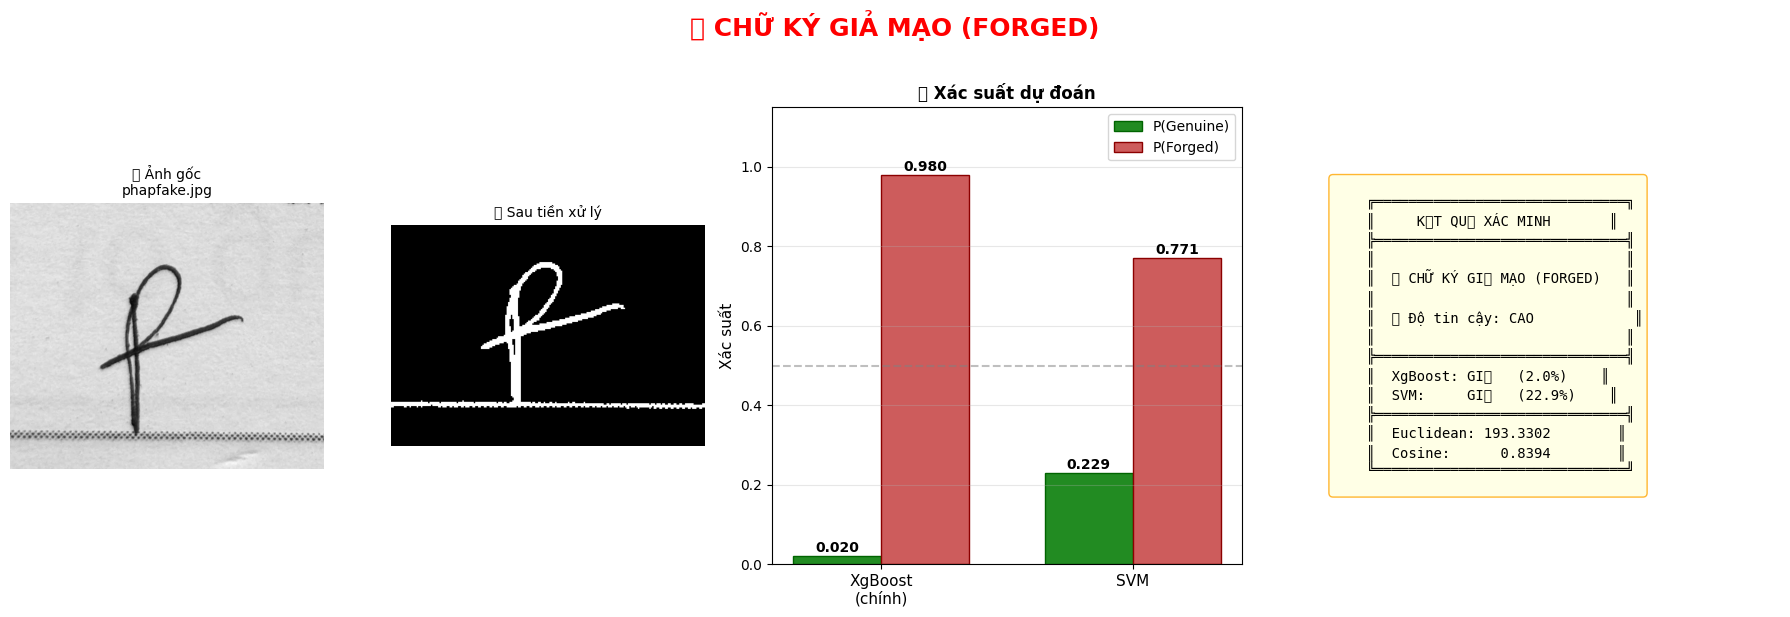


  📌 XgBoost: GIẢ ❌ (P_genuine=0.0202, P_forged=0.9798)
  📌 SVM:     GIẢ ❌ (P_genuine=0.2286, P_forged=0.7714)
  📏 Khoảng cách Euclidean: 193.3302
  📐 Cosine Similarity:     0.8394


In [34]:
# ============================================================
# CELL 24: Hiển thị kết quả xác minh chi tiết
# ============================================================

if len(query_results) == 0:
    print("❌ Không có ảnh nào để hiển thị. Hãy chạy lại Cell 23.")
else:
    n_queries = len(query_results)

    for idx, result in enumerate(query_results):
        print(f"\n{'='*70}")
        print(f"📋 KẾT QUẢ XÁC MINH - Ảnh {idx+1}/{n_queries}: {result['filename']}")
        print(f"{'='*70}")

        # ===== Kết quả tổng hợp =====
        xgb_genuine = result['xgb_pred'] == 1
        svm_genuine = result['svm_pred'] == 1

        # Quyết định cuối cùng: ưu tiên XgBoost (mô hình tốt hơn)
        # nhưng cũng xem xét SVM
        final_genuine = xgb_genuine  # XgBoost là mô hình chính

        if xgb_genuine and svm_genuine:
            confidence = "CAO"
            conf_emoji = "🟢"
        elif xgb_genuine or svm_genuine:
            confidence = "TRUNG BÌNH"
            conf_emoji = "🟡"
        else:
            confidence = "CAO"
            conf_emoji = "🟢"

        if final_genuine:
            verdict = "✅ CHỮ KÝ THẬT (GENUINE)"
            verdict_color = 'green'
        else:
            verdict = "❌ CHỮ KÝ GIẢ MẠO (FORGED)"
            verdict_color = 'red'

        # Vẽ kết quả
        fig = plt.figure(figsize=(18, 6))
        gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1.5, 1.5])

        # Ảnh gốc
        ax1 = fig.add_subplot(gs[0])
        ax1.imshow(result['img_raw'], cmap='gray')
        ax1.set_title(f'📷 Ảnh gốc\n{result["filename"]}', fontsize=10)
        ax1.axis('off')

        # Ảnh tiền xử lý
        ax2 = fig.add_subplot(gs[1])
        ax2.imshow(result['img_processed'], cmap='gray')
        ax2.set_title('🔄 Sau tiền xử lý', fontsize=10)
        ax2.axis('off')

        # Bi��u đồ xác suất
        ax3 = fig.add_subplot(gs[2])
        models_name = ['XgBoost\n(chính)', 'SVM']
        genuine_probs = [result['xgb_prob'][1], result['svm_prob'][1]]
        forged_probs = [result['xgb_prob'][0], result['svm_prob'][0]]

        x_pos = np.arange(len(models_name))
        width = 0.35
        bars_g = ax3.bar(x_pos - width/2, genuine_probs, width,
                          label='P(Genuine)', color='forestgreen',
                          edgecolor='darkgreen')
        bars_f = ax3.bar(x_pos + width/2, forged_probs, width,
                          label='P(Forged)', color='indianred',
                          edgecolor='darkred')

        for bar in bars_g:
            ax3.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                     f'{bar.get_height():.3f}', ha='center', fontsize=10,
                     fontweight='bold')
        for bar in bars_f:
            ax3.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                     f'{bar.get_height():.3f}', ha='center', fontsize=10,
                     fontweight='bold')

        ax3.set_xticks(x_pos)
        ax3.set_xticklabels(models_name, fontsize=11)
        ax3.set_ylabel('Xác suất', fontsize=11)
        ax3.set_ylim([0, 1.15])
        ax3.set_title('📊 Xác suất dự đoán', fontsize=12, fontweight='bold')
        ax3.legend(loc='upper right', fontsize=10)
        ax3.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
        ax3.grid(axis='y', alpha=0.3)

        # Bảng kết quả
        ax4 = fig.add_subplot(gs[3])
        ax4.axis('off')

        result_text = f"""
    ╔══════════════════════════════╗
    ║     KẾT QUẢ XÁC MINH       ║
    ╠══════════════════════════════╣
    ║                              ║
    ║  {verdict:<27s} ║
    ║                              ║
    ║  {conf_emoji} Độ tin cậy: {confidence:<14s} ║
    ║                              ║
    ╠══════════════════════════════╣
    ║  XgBoost: {'THẬT' if xgb_genuine else 'GIẢ ':>4s}  ({result['xgb_prob'][1]:.1%})    ║
    ║  SVM:     {'THẬT' if svm_genuine else 'GIẢ ':>4s}  ({result['svm_prob'][1]:.1%})    ║
    ╠══════════════════════════════╣
    ║  Euclidean: {result['euclidean_dist']:>8.4f}        ║
    ║  Cosine:    {result['cosine_sim']:>8.4f}        ║
    ╚══════════════════════════════╝
        """

        ax4.text(0.05, 0.5, result_text, transform=ax4.transAxes,
                 fontsize=10, verticalalignment='center',
                 fontfamily='monospace',
                 bbox=dict(boxstyle='round', facecolor='lightyellow',
                           edgecolor='orange', alpha=0.8))

        plt.suptitle(verdict, fontsize=18, fontweight='bold',
                      color=verdict_color, y=1.02)
        plt.tight_layout()
        plt.show()

        # In thông tin chi tiết
        print(f"\n  📌 XgBoost: {'THẬT ✅' if xgb_genuine else 'GIẢ ❌'} "
              f"(P_genuine={result['xgb_prob'][1]:.4f}, P_forged={result['xgb_prob'][0]:.4f})")
        print(f"  📌 SVM:     {'THẬT ✅' if svm_genuine else 'GIẢ ❌'} "
              f"(P_genuine={result['svm_prob'][1]:.4f}, P_forged={result['svm_prob'][0]:.4f})")
        print(f"  📏 Khoảng cách Euclidean: {result['euclidean_dist']:.4f}")
        print(f"  📐 Cosine Similarity:     {result['cosine_sim']:.4f}")

✅ Hồ sơ chữ ký sẵn sàng (từ 5 mẫu tham chiếu)

📤 Upload ảnh chữ ký cần xác minh:


Saving tienfake.jpg to tienfake.jpg


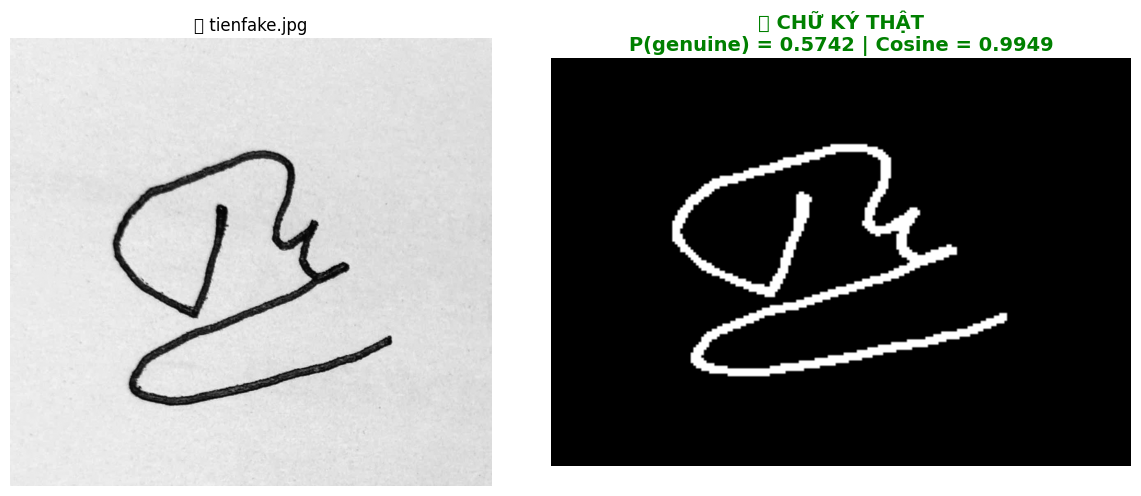

  → XgBoost: P(genuine)=0.5742, P(forged)=0.4258



In [29]:
# ============================================================
# CELL 25: Xác minh lại (chạy lại cell này mỗi khi muốn test)
# ============================================================
"""
🔄 Chạy cell này mỗi khi muốn kiểm tra chữ ký mới
   mà KHÔNG CẦN upload lại chữ ký tham chiếu
"""

display(HTML("""
<div style="background: #e3f2fd; padding: 20px; border-radius: 10px;
            border-left: 5px solid #2196f3; margin: 10px 0;">
    <h3 style="color: #1565c0;">🔄 XÁC MINH LẠI - Upload chữ ký mới để kiểm tra</h3>
    <p>Hồ sơ chữ ký của bạn vẫn được giữ nguyên từ BƯỚC 1</p>
    <p>Chỉ cần upload ảnh chữ ký mới cần kiểm tra</p>
</div>
"""))

# Kiểm tra đã có signature profile chưa
if 'my_signature_profile' not in dir() or my_signature_profile is None:
    print("❌ Chưa tạo hồ sơ chữ ký! Hãy chạy Cell 21 và 22 trước.")
else:
    print(f"✅ Hồ sơ chữ ký sẵn sàng (từ {len(ref_embeddings)} mẫu tham chiếu)")
    print(f"\n📤 Upload ảnh chữ ký cần xác minh:")

    uploaded_new = files.upload()

    for filename, content in uploaded_new.items():
        if not filename.lower().endswith(SUPPORTED_EXT):
            continue

        img_array = np.frombuffer(content, dtype=np.uint8)
        img_raw = cv2.imdecode(img_array, cv2.IMREAD_GRAYSCALE)
        if img_raw is None:
            continue

        # Tiền xử lý
        img_resized = cv2.resize(img_raw, (220, 155), interpolation=cv2.INTER_LINEAR)
        img_blur = cv2.GaussianBlur(img_resized, (3, 3), 0)
        _, img_binary = cv2.threshold(img_blur, 0, 255,
                                       cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        if np.mean(img_binary) > 127:
            img_binary = 255 - img_binary

        coords = cv2.findNonZero(img_binary)
        if coords is not None:
            x, y, w, h = cv2.boundingRect(coords)
            sig = img_binary[y:y+h, x:x+w]
            result_img = np.zeros_like(img_binary)
            y_off = (img_binary.shape[0] - h) // 2
            x_off = (img_binary.shape[1] - w) // 2
            h_p = min(h, img_binary.shape[0] - y_off)
            w_p = min(w, img_binary.shape[1] - x_off)
            result_img[y_off:y_off+h_p, x_off:x_off+w_p] = sig[:h_p, :w_p]
            img_binary = result_img

        img_norm = img_binary.astype(np.float32) / 255.0

        # Embedding + Dự đoán
        with torch.no_grad():
            tensor = torch.FloatTensor(img_norm).unsqueeze(0).unsqueeze(0).to(device)
            emb = model.extract_features(tensor).cpu().numpy().flatten()

        feat = np.abs(my_signature_profile - emb).reshape(1, -1)
        feat_scaled = scaler.transform(feat)

        xgb_pred = xgb_model.predict(feat_scaled)[0]
        xgb_prob = xgb_model.predict_proba(feat_scaled)[0]
        cos_sim = np.dot(my_signature_profile, emb) / (
            np.linalg.norm(my_signature_profile) * np.linalg.norm(emb))

        # Hiển thị nhanh
        is_genuine = xgb_pred == 1
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        axes[0].imshow(img_raw, cmap='gray')
        axes[0].set_title(f'📷 {filename}', fontsize=12)
        axes[0].axis('off')

        axes[1].imshow(img_norm, cmap='gray')
        if is_genuine:
            axes[1].set_title(
                f'✅ CHỮ KÝ THẬT\n'
                f'P(genuine) = {xgb_prob[1]:.4f} | Cosine = {cos_sim:.4f}',
                fontsize=14, fontweight='bold', color='green')
        else:
            axes[1].set_title(
                f'❌ CHỮ KÝ GIẢ MẠO\n'
                f'P(genuine) = {xgb_prob[1]:.4f} | Cosine = {cos_sim:.4f}',
                fontsize=14, fontweight='bold', color='red')
        axes[1].axis('off')

        plt.tight_layout()
        plt.show()

        print(f"  → XgBoost: P(genuine)={xgb_prob[1]:.4f}, P(forged)={xgb_prob[0]:.4f}")
        print()

In [30]:
# ============================================================
# CELL 26: (Bonus) Xác minh hàng loạt từ thư mục Google Drive
# ============================================================
"""
Nếu bạn có nhiều ảnh cần kiểm tra, có thể mount Google Drive
và kiểm tra hàng loạt từ một thư mục
"""

USE_DRIVE = False  # Đổi thành True nếu muốn dùng Google Drive

if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')

    # ĐỔI ĐƯỜNG DẪN NÀY CHO PHÙ HỢP
    QUERY_FOLDER = '/content/drive/MyDrive/signatures_to_verify/'

    if not os.path.exists(QUERY_FOLDER):
        print(f"❌ Thư mục không tồn tại: {QUERY_FOLDER}")
        print("   Hãy tạo thư mục và đặt ảnh vào đó!")
    else:
        print(f"📂 Đang quét thư mục: {QUERY_FOLDER}")

        results_batch = []

        for filename in sorted(os.listdir(QUERY_FOLDER)):
            if not filename.lower().endswith(SUPPORTED_EXT):
                continue

            filepath = os.path.join(QUERY_FOLDER, filename)
            img_raw = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)
            if img_raw is None:
                continue

            # Tiền xử lý
            img_resized = cv2.resize(img_raw, (220, 155), interpolation=cv2.INTER_LINEAR)
            img_blur = cv2.GaussianBlur(img_resized, (3, 3), 0)
            _, img_binary = cv2.threshold(img_blur, 0, 255,
                                           cv2.THRESH_BINARY + cv2.THRESH_OTSU)
            if np.mean(img_binary) > 127:
                img_binary = 255 - img_binary

            coords = cv2.findNonZero(img_binary)
            if coords is not None:
                x, y, w, h = cv2.boundingRect(coords)
                sig = img_binary[y:y+h, x:x+w]
                res = np.zeros_like(img_binary)
                y_o = (img_binary.shape[0] - h) // 2
                x_o = (img_binary.shape[1] - w) // 2
                h_p = min(h, img_binary.shape[0] - y_o)
                w_p = min(w, img_binary.shape[1] - x_o)
                res[y_o:y_o+h_p, x_o:x_o+w_p] = sig[:h_p, :w_p]
                img_binary = res

            img_norm = img_binary.astype(np.float32) / 255.0

            with torch.no_grad():
                tensor = torch.FloatTensor(img_norm).unsqueeze(0).unsqueeze(0).to(device)
                emb = model.extract_features(tensor).cpu().numpy().flatten()

            feat = np.abs(my_signature_profile - emb).reshape(1, -1)
            feat_scaled = scaler.transform(feat)

            pred = xgb_model.predict(feat_scaled)[0]
            prob = xgb_model.predict_proba(feat_scaled)[0]
            cos_sim = np.dot(my_signature_profile, emb) / (
                np.linalg.norm(my_signature_profile) * np.linalg.norm(emb))

            results_batch.append({
                'file': filename,
                'verdict': 'THẬT ✅' if pred == 1 else 'GIẢ ❌',
                'p_genuine': prob[1],
                'cosine': cos_sim
            })

        # Bảng kết quả
        print(f"\n{'='*70}")
        print(f"📊 KẾT QUẢ XÁC MINH HÀNG LOẠT ({len(results_batch)} ảnh)")
        print(f"{'='*70}")
        print(f"{'STT':<5} {'File':<30} {'Kết quả':<12} {'P(genuine)':<12} {'Cosine':<10}")
        print(f"{'-'*70}")

        for i, r in enumerate(results_batch, 1):
            print(f"{i:<5} {r['file']:<30} {r['verdict']:<12} "
                  f"{r['p_genuine']:<12.4f} {r['cosine']:<10.4f}")

        n_genuine = sum(1 for r in results_batch if 'THẬT' in r['verdict'])
        n_forged = len(results_batch) - n_genuine
        print(f"\n📌 Tổng kết: {n_genuine} THẬT | {n_forged} GIẢ")

else:
    print("ℹ️ Cell này dành cho xác minh hàng loạt từ Google Drive.")
    print("   Đổi USE_DRIVE = True và chỉnh QUERY_FOLDER để sử dụng.")

ℹ️ Cell này dành cho xác minh hàng loạt từ Google Drive.
   Đổi USE_DRIVE = True và chỉnh QUERY_FOLDER để sử dụng.
